# **Laboratorio 7 - NLP end-to-end y Embeddings**

CC3092 - Deep Learning y Sistemas Inteligentes

Integrantes: Bryan Martínez 23542 y Adriana Palacios 23044

## **Configuración**

In [27]:
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 123
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

DIR_DATOS = Path("datos")
DIR_MODELOS = Path("modelos")
DIR_RESULTADOS = Path("resultados")
DIR_FIGURAS = Path("figuras")
for directorio in (DIR_DATOS, DIR_MODELOS, DIR_RESULTADOS, DIR_FIGURAS):
    directorio.mkdir(exist_ok=True)

# Pipeline de preprocesamiento (sección 2)
TOKENS_SUBCONJUNTO = 20_000_000
MIN_COUNT = 5
UMBRAL_SUBMUESTREO = 1e-3
VENTANA = 5

# Entrenamiento de SGNS (sección 4)
DIM_BASE = 100
NEGATIVOS = 5
EPOCHS = 5
BATCH_SIZE = 32_768
LEARNING_RATE = 2e-3
PASOS_REGISTRO = 100
VOCAB_EVALUACION = 30_000
PALABRAS_CONTROL = ["king", "france", "computer", "good", "january", "run"]

def fijar_semilla(seed=SEED):
    """Fija la semilla global para reproducibilidad."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

fijar_semilla()
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Dispositivo: mps
PyTorch: 2.14.0


---
# **1. Datos**

En esta sección se cargan los cuatro recursos del laboratorio: el corpus de texto crudo con el que se entrenarán los embeddings propios (WikiText-103), el dataset de clasificación donde se usarán en una tarea real (AG News), el modelo preentrenado de referencia (GloVe de 100 dimensiones) y los benchmarks de evaluación incluidos en gensim. Los datasets de Hugging Face y GloVe se descargan dentro de `datos/`, que está excluido del repositorio.

In [2]:
import os

from datasets import load_dataset

DIR_CACHE_HF = DIR_DATOS / "huggingface"
os.environ.setdefault("GENSIM_DATA_DIR", str((DIR_DATOS / "gensim-data").resolve()))

import gensim.downloader as api
from gensim.test.utils import datapath

## **Corpus: WikiText-103**

In [3]:
corpus = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", cache_dir=DIR_CACHE_HF)
corpus

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-103-raw-v1/test-00000-of-00001.(…): downloading bytes:           |  0.00B            

wikitext-103-raw-v1/train-00000-of-00002(…): reconstructing file:   0%|          |  0.00B /  157MB            

wikitext-103-raw-v1/train-00000-of-00002(…): downloading bytes:           |  0.00B            

...

wikitext-103-raw-v1/validation-00000-of-(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

In [4]:
# Se usa repr para que se vean los saltos de línea y las líneas vacías tal como vienen en el corpus
for i, linea in enumerate(corpus["train"][:12]["text"]):
    print(f"{i}: {linea[:160]!r}")

0: ''
1: ' = Valkyria Chronicles III = \n'
2: ''
3: ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III '
4: ' The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the '
5: ' It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an e'
6: ''
7: ' = = Gameplay = = \n'
8: ''
9: ' As with previous Valkyira Chronicles games , Valkyria Chronicles III is a tactical role @-@ playing game where players take control of a military unit and take'
10: " The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles . During missions , players select each unit using a top @-@ d"
11: ' Troops are divided into five classes : Scouts , Shocktroopers , Engineers , 

## **Clasificación: AG News**

In [5]:
news = load_dataset("fancyzhx/ag_news", cache_dir=DIR_CACHE_HF)
NOMBRES_CLASES = news["train"].features["label"].names
print(f"Clases: {NOMBRES_CLASES}")
news

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Clases: ['World', 'Sports', 'Business', 'Sci/Tech']


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [6]:
pd.set_option("display.max_colwidth", 220)

muestra_news = news["train"].to_pandas().groupby("label").head(2).sort_values("label")
muestra_news["clase"] = muestra_news["label"].map(lambda i: NOMBRES_CLASES[i])
muestra_news[["clase", "text"]].reset_index(drop=True)

,clase,text
0,World,Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Ch...
1,World,"S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used water cannon in\central Seoul Sunday to disperse at least 7,000 protesters\urging the government to reverse a controvers..."
2,Sports,"Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evenin..."
3,Sports,"Reds Knock Padres Out of Wild-Card Lead (AP) AP - Wily Mo Pena homered twice and drove in four runs, helping the Cincinnati Reds beat the San Diego Padres 11-5 on Saturday night. San Diego was knocked out of a share ..."
4,Business,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
5,Business,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quie..."
6,Sci/Tech,"'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because ""Madden NFL 2005"" came out tha..."
7,Sci/Tech,"Group to Propose New High-Speed Wireless Format (Reuters) Reuters - A group of technology companies\including Texas Instruments Inc. (TXN.N), STMicroelectronics\(STM.PA) and Broadcom Corp. (BRCM.O), on Thursday said ..."


## **Modelo preentrenado: GloVe**

In [7]:
glove = api.load("glove-wiki-gigaword-100")

print(f"Tamaño del vocabulario: {len(glove.key_to_index):,}")
print(f"Dimensión: {glove.vector_size}")
print(f"Primeras 15 palabras (las más frecuentes): {glove.index_to_key[:15]}")
print(f"Primeros 8 valores de vec(king): {np.round(glove['king'][:8], 3)}")
pd.DataFrame(glove.most_similar("king", topn=5), columns=["palabra", "similitud_coseno"])

[==================================================] 100.0% 128.1/128.1MB downloaded
Tamaño del vocabulario: 400,000
Dimensión: 100
Primeras 15 palabras (las más frecuentes): ['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s", 'for', '-', 'that', 'on', 'is']
Primeros 8 valores de vec(king): [-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]


,palabra,similitud_coseno
0,prince,0.768233
1,queen,0.750769
2,son,0.702089
3,brother,0.698578
4,monarch,0.697789


## **Benchmarks de evaluación**

In [8]:
analogias = datapath("questions-words.txt")
wordsim = datapath("wordsim353.tsv")
simlex = datapath("simlex999.txt")

lineas_analogias = Path(analogias).read_text(encoding="utf-8").splitlines()
categorias = [linea[2:] for linea in lineas_analogias if linea.startswith(":")]
print(f"Analogías: {len(lineas_analogias) - len(categorias):,} en {len(categorias)} categorías")
print(f"Categorías: {categorias}")
print(f"Ejemplo: {lineas_analogias[1]} (Athens es a Greece como Baghdad es a Iraq)")

columnas = ["palabra_1", "palabra_2", "puntaje_humano"]
df_wordsim = pd.read_csv(wordsim, sep="\t", comment="#", header=None, names=columnas)
df_simlex = pd.read_csv(simlex, sep="\t", comment="#", header=None, names=columnas)
print(f"Pares WordSim-353: {len(df_wordsim)}")
print(f"Pares SimLex-999: {len(df_simlex)}")

pd.concat({"WordSim-353": df_wordsim.head(4), "SimLex-999": df_simlex.head(4)})

Analogías: 19,544 en 14 categorías
Categorías: ['capital-common-countries', 'capital-world', 'currency', 'city-in-state', 'family', 'gram1-adjective-to-adverb', 'gram2-opposite', 'gram3-comparative', 'gram4-superlative', 'gram5-present-participle', 'gram6-nationality-adjective', 'gram7-past-tense', 'gram8-plural', 'gram9-plural-verbs']
Ejemplo: Athens Greece Baghdad Iraq (Athens es a Greece como Baghdad es a Iraq)
Pares WordSim-353: 353
Pares SimLex-999: 999


palabra_1    palabra_2  puntaje_humano
WordSim-353 0      love          sex            6.77
            1     tiger          cat            7.35
            2     tiger        tiger           10.00
            3      book        paper            7.46
SimLex-999  0       old          new            1.58
            1     smart  intelligent            9.20
            2      hard    difficult            8.77
            3     happy     cheerful            9.55

---
# **2. Exploración y preprocesamiento del texto**

**¿Cuántos artículos, líneas y tokens tiene el corpus?**

- **Artículos:** WikiText-103 contiene 28,592 artículos, de los cuales 28,472 pertenecen a train y 60 a cada uno de validation y test. Se identificaron como las líneas de título con un solo `=` a cada lado rodeadas por líneas vacías, ya que el regex por sí solo también capturaba fórmulas que inician con `=`.
- **Líneas:** el corpus tiene 1,809,468 líneas, de las cuales únicamente 1,170,381 contienen texto, ya que aproximadamente el 35 % son líneas vacías que separan párrafos y títulos.
- **Tokens:** separando por espacios, el corpus tiene 101,880,768 tokens, 101,425,671 de ellos en train. Esto coincide con los 103,227,021 reportados por los autores para train si se suma un token de fin de línea por cada una de las 1,801,350 líneas. Cabe mencionar que este conteo incluye los marcadores `=` de los títulos y los `@-@`, por lo que cambiará después de la normalización.

In [9]:
import re

# Un título de artículo tiene un solo "=" a cada lado y va entre líneas vacías;
# esto descarta subtítulos ("= = X = =") y ecuaciones que empiezan con "="
PATRON_TITULO = re.compile(r"^ = [^=].* = $")


def estadisticas_split(lineas):
    """Cuenta artículos, líneas y tokens (separados por espacios) de un split."""
    lineas = list(lineas)
    articulos = lineas_con_texto = tokens = 0
    for i, linea in enumerate(lineas):
        if not linea.strip():
            continue
        lineas_con_texto += 1
        tokens += len(linea.split())
        anterior_vacia = i == 0 or lineas[i - 1] == ""
        siguiente_vacia = i == len(lineas) - 1 or lineas[i + 1] == ""
        if anterior_vacia and siguiente_vacia and PATRON_TITULO.match(linea.rstrip("\n")):
            articulos += 1
    return {"articulos": articulos, "lineas": len(lineas),
            "lineas_con_texto": lineas_con_texto, "tokens": tokens}


tabla_corpus = pd.DataFrame(
    {split: estadisticas_split(corpus[split]["text"]) for split in ["train", "validation", "test"]}
).T
tabla_corpus.loc["total"] = tabla_corpus.sum()
tabla_corpus.index.name = "split"
tabla_corpus.style.format("{:,}")

,articulos,lineas,lineas_con_texto,tokens
split,,,,
train,"28,472","1,801,350","1,165,029","101,425,671"
validation,60,"3,760","2,461","213,886"
test,60,"4,358","2,891","241,211"
total,"28,592","1,809,468","1,170,381","101,880,768"


**Definan y justifiquen su normalización: minúsculas, puntuación, números y tokens especiales. ¿Qué decisiones deben ser consistentes con el vocabulario de GloVe para que la comparación sea justa?**

- **Minúsculas:** todo el texto se convierte a minúsculas, de tal forma que palabras como "Dog" y "dog" se traten como un mismo token. Asimismo, GloVe no contiene ninguna palabra con mayúsculas, por lo que esta decisión aumenta la cobertura de los tokens de WikiText en su vocabulario de 81.75 % a 98.0 % (medido en las primeras 300,000 líneas de train).
- **Puntuación:** se eliminan los tokens formados únicamente por signos de puntuación, que representan el 14.74 % de los tokens, ya que no aportan información sobre el significado de las palabras que los rodean. No obstante, se conservan los signos que forman parte de una palabra, como el guion de "role-playing", el apóstrofo de "'s" y "n't" o el punto decimal de "3.5".
- **Stopwords:** no se eliminan. Aunque palabras como "the" aportan poco por sí solas, las listas de stopwords incluyen palabras como "he", "she", "his", "her" y "not", que son justamente las que diferencian el contexto de "king" del de "queen". Es por esto que el exceso de palabras frecuentes se maneja con el submuestreo de Word2Vec, que descarta parte de sus apariciones sin eliminarlas del vocabulario.
- **Números:** se mantienen como tokens, ya que GloVe contiene 48,970 palabras con dígitos (por ejemplo "1990" o "1,000") y reemplazarlos por un token como `<num>` los convertiría en palabras fuera de su vocabulario. Los números poco frecuentes se convierten en `<unk>` al aplicar `min_count`.
- **Tokens especiales:** los marcadores `@-@`, `@,@` y `@.@` se reúnen con las palabras vecinas ("role-playing", "1,000", "3.5") y las contracciones como "don 't" se convierten a "do n't", para coincidir con el formato de GloVe. Asimismo, se descartan las líneas de título y subtítulo (`= ... =`), ya que encabezados como "Reception" o "Early life" se repiten en miles de artículos y generarían co-ocurrencias artificiales, y se elimina el marcador `<formula>`. Por último, se agregan `<unk>` para las palabras por debajo de `min_count` y `<pad>` para el relleno en el clasificador.

Para que la comparación con GloVe sea justa deben ser consistentes las minúsculas y el formato de las palabras compuestas, los números y las contracciones, ya que cualquier diferencia hace que una palabra exista en un vocabulario y no en el otro. Es por esto que se utiliza un único pipeline de normalización y tokenización para WikiText y AG News, con un paso previo de limpieza específico para cada fuente, de tal forma que las diferencias de cobertura y de desempeño se deban a los embeddings y no al preprocesamiento.

In [10]:
from collections import Counter

N_LINEAS_MUESTRA = 300_000

conteo_muestra = Counter()
for linea in corpus["train"][:N_LINEAS_MUESTRA]["text"]:
    conteo_muestra.update(linea.split())
total_muestra = sum(conteo_muestra.values())

conteo_minusculas = Counter()
for token, n in conteo_muestra.items():
    conteo_minusculas[token.lower()] += n

vocab_glove = glove.key_to_index


def porcentaje(conteo, condicion):
    """Porcentaje de los tokens de la muestra que cumplen la condición."""
    return round(100 * sum(n for token, n in conteo.items() if condicion(token)) / total_muestra, 2)


def es_puntuacion(token):
    return not any(ch.isalnum() for ch in token)


def tiene_digito(token):
    return any(ch.isdigit() for ch in token)


print(f"Tokens en la muestra de WikiText: {total_muestra:,}")
ejemplos = ["role-playing", "1,000", "3.5", "n't", "'t", "@-@"]
print(f"Formas presentes en GloVe: {[p for p in ejemplos if p in vocab_glove]}")
print(f"Formas ausentes en GloVe: {[p for p in ejemplos if p not in vocab_glove]}")

pd.DataFrame([
    ("WikiText", "Tokens con mayúscula (%)", porcentaje(conteo_muestra, lambda t: t != t.lower())),
    ("WikiText", "Cobertura en GloVe sin minúsculas (%)", porcentaje(conteo_muestra, lambda t: t in vocab_glove)),
    ("WikiText", "Cobertura en GloVe con minúsculas (%)", porcentaje(conteo_minusculas, lambda t: t in vocab_glove)),
    ("WikiText", "Tokens de puntuación pura (%)", porcentaje(conteo_muestra, es_puntuacion)),
    ("WikiText", "Tokens con dígitos (%)", porcentaje(conteo_muestra, tiene_digito)),
    ("WikiText", "Marcadores @-@, @,@ y @.@ (%)", porcentaje(conteo_muestra, lambda t: t in {"@-@", "@,@", "@.@"})),
    ("WikiText", "Apariciones de 't (contracciones)", conteo_minusculas["'t"]),
    ("GloVe", "Palabras con mayúscula", sum(w != w.lower() for w in vocab_glove)),
    ("GloVe", "Palabras de puntuación pura", sum(es_puntuacion(w) for w in vocab_glove)),
    ("GloVe", "Palabras con dígitos", sum(tiene_digito(w) for w in vocab_glove)),
    ("GloVe", "Palabras con guion", sum("-" in w and len(w) > 1 for w in vocab_glove)),
], columns=["fuente", "aspecto", "valor"], dtype=object)

Tokens en la muestra de WikiText: 16,763,047
Formas presentes en GloVe: ['role-playing', '1,000', '3.5', "n't"]
Formas ausentes en GloVe: ["'t", '@-@']


,fuente,aspecto,valor
0,WikiText,Tokens con mayúscula (%),16.79
1,WikiText,Cobertura en GloVe sin minúsculas (%),81.75
2,WikiText,Cobertura en GloVe con minúsculas (%),98.0
3,WikiText,Tokens de puntuación pura (%),14.74
4,WikiText,Tokens con dígitos (%),3.27
5,WikiText,"Marcadores @-@, @,@ y @.@ (%)",1.18
6,WikiText,Apariciones de 't (contracciones),5088
7,GloVe,Palabras con mayúscula,0
8,GloVe,Palabras de puntuación pura,177
9,GloVe,Palabras con dígitos,48970


**Implementen un tokenizador por palabra y compárenlo con uno de librería (spaCy o NLTK) en al menos 10 oraciones de ejemplo. ¿En qué casos difieren (contracciones, guiones, abreviaturas)?**

Se implementó la función `tokenizar`, que convierte el texto a minúsculas, separa los tokens mediante un regex que reconoce contracciones, clíticos, siglas, abreviaturas, números con separador y palabras compuestas con guion, y descarta la puntuación pura. Esta se comparó con `word_tokenize` de NLTK en 12 oraciones: 3 en formato WikiText, 3 noticias reales de AG News y 6 oraciones propias diseñadas para provocar diferencias. La diferencia principal se encuentra en los signos de puntuación, ya que NLTK conserva comas, puntos, paréntesis y guiones sueltos como tokens (entre 1 y 8 por oración, 41 en total), mientras que nuestro tokenizador los descarta. Sin considerar la puntuación, las palabras coinciden en 9 de las 12 oraciones, y las diferencias restantes se dan en los siguientes casos:

- **Contracciones:** en el formato pre-tokenizado de WikiText, NLTK separa "doesn 't" en `doesn` y `'t`, mientras que nuestro tokenizador lo convierte a `does` y `n't`, que es la forma que utiliza GloVe. En las contracciones escritas de forma normal, como "don't" o "won't", ambos coinciden.
- **Abreviaturas:** ambos conservan "Dr.", "Mr.", "Jan." y "U.S.", pero NLTK separa el punto final de "e.g." e "i.e.", mientras que nuestro tokenizador las mantiene completas, tal como aparecen en GloVe.
- **Guiones:** las palabras compuestas como "state-of-the-art" o "short-sellers" se mantienen unidas en ambos. No obstante, si a NLTK se le pasa el texto de WikiText sin limpiar, separa los marcadores `@-@`, `@,@` y `@.@`, de tal forma que "role @-@ playing" se convierte en cinco tokens y "1 @,@ 000" en `1`, `@`, `,`, `@`, `000`, ya que no conoce el formato propio del corpus.

El único caso en el que NLTK resulta más fiel es "rock'n'roll", que conserva como una sola palabra, mientras que nuestro tokenizador lo separa en `rock`, `n` y `roll`. Cabe mencionar que esta palabra tampoco existe en GloVe, por lo que no afecta la comparación.

In [11]:
import re

from nltk.tokenize import word_tokenize

PATRON_ENCABEZADO = re.compile(r"^\s*=.*=\s*$")
PATRON_MARCADOR_WIKI = re.compile(r" @([-,.])@ ")
PATRON_ENTIDAD_NUMERICA = re.compile(r"&?#(\d+);")
PATRON_ENTIDAD_NOMBRE = re.compile(r"&?(quot|amp|lt|gt);")
PATRON_HTML = re.compile(r"<[^>]*>")
ENTIDADES = {"quot": '"', "amp": "&", "lt": "<", "gt": ">"}

ABREVIATURAS = ["mr", "mrs", "ms", "dr", "st", "jr", "sr", "inc", "co", "corp", "ltd", "vs", "etc",
                "jan", "feb", "aug", "sept", "oct", "nov", "dec"]

PATRON_TOKEN = re.compile(rf"""
    [^\W\d_]+(?=n't\b)                       # parte previa de una contracción: "do" en "don't"
  | n't\b                                    # contracción negativa
  | '(?:s|re|ll|ve|m|d)\b                    # clíticos: 's, 're, 'll, 've, 'm, 'd
  | (?:[^\W\d_]\.){{2,}}                     # siglas con puntos: u.s., e.g., a.m.
  | \b(?:{"|".join(ABREVIATURAS)})\.         # abreviaturas que GloVe conserva con punto
  | \d+(?:[.,]\d+)+                          # números con separador: 1,000 y 3.5
  | o'[^\W_]+                                # apellidos como o'neill
  | [^\W_]+(?:-[^\W_]+)*                     # palabras, incluyendo compuestas con guion
  | \S                                       # cualquier otro símbolo (se descarta después)
""", re.VERBOSE)


def limpiar_wikitext(linea):
    """Descarta encabezados y reúne los marcadores @-@, @,@ y @.@ de WikiText."""
    if PATRON_ENCABEZADO.match(linea):
        return ""
    linea = linea.replace("<formula>", " ")
    return PATRON_MARCADOR_WIKI.sub(r"\1", linea)


def decodificar_entidad(numero):
    """Convierte el código de una entidad HTML en su carácter (128-159 vienen de cp1252)."""
    n = int(numero)
    if 128 <= n < 160:
        return bytes([n]).decode("cp1252", errors="ignore")
    return chr(n)


def limpiar_agnews(texto):
    """Repara las entidades HTML rotas, las etiquetas y las barras invertidas de AG News."""
    texto = PATRON_ENTIDAD_NUMERICA.sub(lambda m: decodificar_entidad(m.group(1)), texto)
    texto = PATRON_ENTIDAD_NOMBRE.sub(lambda m: ENTIDADES[m.group(1)], texto)
    texto = PATRON_HTML.sub(" ", texto)
    return texto.replace("\\", " ")


def tokenizar(texto):
    """Pasa a minúsculas, separa en tokens de palabra y descarta la puntuación pura."""
    texto = texto.lower().replace("\u2019", "'")
    texto = re.sub(r"n\s+'t\b", "n't", texto)
    return [token for token in PATRON_TOKEN.findall(texto) if any(ch.isalnum() for ch in token)]

In [12]:
from collections import Counter

ORACIONES = [
    ("WikiText", " The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles . "),
    ("WikiText", " Valkyria Chronicles III is a tactical role @-@ playing game released in 2011 . "),
    ("WikiText", " The stadium holds 1 @,@ 000 people and cost $ 3 @.@ 5 million , but it doesn 't have a roof . "),
    ("AG News", "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."),
    ("AG News", "Last Call for Investors to Bid on Google NEW YORK (Reuters) - Time is running out for prospective investors to submit their offers to buy shares of Google Inc, the Web #39;s No. 1 search company."),
    ("AG News", "Letters Target the abusers of legal weapons We can all share the outrage, expressed by columnist Steve Bailey (''Summer Sizzler, quot; Aug. 11), at the killings in the city's poor neighborhoods."),
    ("Propia", "I don't think the U.S. economy can't recover, Dr. Smith said."),
    ("Propia", "She won't sell her state-of-the-art e-mail service for $3.5 million."),
    ("Propia", "In the 1990s, O'Neill's team scored 1,000 points vs. Boston."),
    ("Propia", "Mr. and Mrs. Brown arrived at 9 a.m. on Jan. 5, i.e. very early."),
    ("Propia", "It's a well-known fact: rock'n'roll isn't dead!"),
    ("Propia", "The COVID-19 pandemic hit the U.K. in 2020 (e.g. London)."),
]
LIMPIEZA = {"WikiText": limpiar_wikitext, "AG News": limpiar_agnews, "Propia": limpiar_agnews}


def diferencia(a, b):
    """Tokens de a que no están en b, respetando repeticiones."""
    return list((Counter(a) - Counter(b)).elements())


filas = []
for fuente, oracion in ORACIONES:
    limpia = LIMPIEZA[fuente](oracion)
    propio = tokenizar(limpia)
    nltk_completo = [token.lower() for token in word_tokenize(limpia)]
    nltk_palabras = [token for token in nltk_completo if any(ch.isalnum() for ch in token)]
    print(f"[{fuente}] {oracion.strip()}")
    print(f"  propio: {propio}")
    print(f"  nltk:   {nltk_completo}")
    if fuente == "WikiText":
        print(f"  nltk sin limpiar: {[token.lower() for token in word_tokenize(oracion)]}")
    print()
    filas.append({
        "fuente": fuente,
        "tokens_propio": len(propio),
        "tokens_nltk": len(nltk_completo),
        "puntuacion_nltk": len(nltk_completo) - len(nltk_palabras),
        "solo_propio": diferencia(propio, nltk_palabras),
        "solo_nltk": diferencia(nltk_palabras, propio),
    })

pd.DataFrame(filas)

[WikiText] The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles .
  propio: ['the', 'game', "'s", 'battle', 'system', 'the', 'blitz', 'system', 'is', 'carried', 'over', 'directly', 'from', 'valkyira', 'chronicles']
  nltk:   ['the', 'game', "'s", 'battle', 'system', ',', 'the', 'blitz', 'system', ',', 'is', 'carried', 'over', 'directly', 'from', 'valkyira', 'chronicles', '.']
  nltk sin limpiar: ['the', 'game', "'s", 'battle', 'system', ',', 'the', 'blitz', 'system', ',', 'is', 'carried', 'over', 'directly', 'from', 'valkyira', 'chronicles', '.']

[WikiText] Valkyria Chronicles III is a tactical role @-@ playing game released in 2011 .
  propio: ['valkyria', 'chronicles', 'iii', 'is', 'a', 'tactical', 'role-playing', 'game', 'released', 'in', '2011']
  nltk:   ['valkyria', 'chronicles', 'iii', 'is', 'a', 'tactical', 'role-playing', 'game', 'released', 'in', '2011', '.']
  nltk sin limpiar: ['valkyria', 'chronicles', 'iii', 'is', 'a', 'tactica

,fuente,tokens_propio,tokens_nltk,puntuacion_nltk,solo_propio,solo_nltk
0,WikiText,15,18,3,[],[]
1,WikiText,11,12,1,[],[]
2,WikiText,16,19,3,"[does, n't]","[doesn, 't]"
3,AG News,22,28,6,[],[]
4,AG News,35,41,6,[],[]
5,AG News,31,39,8,[],[]
6,Propia,13,15,2,[],[]
7,Propia,11,13,2,[],[]
8,Propia,11,13,2,[],[]
9,Propia,14,17,3,[i.e.],[i.e]


**Grafiquen la frecuencia de las palabras contra su rango en escala log-log. ¿Se cumple la ley de Zipf? ¿Qué porcentaje de los tokens cubren las 10, 1,000 y 30,000 palabras más frecuentes?**

La ley de Zipf sí se cumple en la mayor parte del vocabulario, ya que entre los rangos 10 y 30,000 la curva sigue una recta con pendiente de -1.009, prácticamente igual al -1 que predice la ley. No obstante, en la cola de palabras raras (a partir del rango 30,000) la frecuencia cae más rápido, con una pendiente de -1.685, debido a que el corpus es finito y 344,055 de las 716,738 palabras distintas aparecen una sola vez.

En cuanto a la cobertura, las 10 palabras más frecuentes cubren el 24.61 % de los 84,607,547 tokens, las 1,000 más frecuentes el 64.01 % y las 30,000 más frecuentes el 94.64 %. Cabe resaltar que las 10 primeras ("the", "of", "and", "in", "to", "a", "was", "on", "'s" y "as") son stopwords que aportan poco contexto de forma individual y, aun así, representan casi la cuarta parte del texto, por lo que se justifica reducir su peso mediante el submuestreo. Por otro lado, con un vocabulario de 30,000 palabras se cubre casi el 95 % del texto, mientras que las más de 680,000 palabras restantes apenas representan el 5.36 %, lo cual justifica aplicar un umbral de frecuencia mínima.

In [13]:
# El conteo sobre todo train tarda aproximadamente 1 minuto; se guarda para no repetirlo
RUTA_FRECUENCIAS = DIR_DATOS / "frecuencias_train.json"

if RUTA_FRECUENCIAS.exists():
    frecuencias = Counter(json.loads(RUTA_FRECUENCIAS.read_text(encoding="utf-8")))
else:
    inicio = time.time()
    frecuencias = Counter()
    for linea in corpus["train"]["text"]:
        linea = limpiar_wikitext(linea)
        if linea.strip():
            frecuencias.update(tokenizar(linea))
    RUTA_FRECUENCIAS.write_text(json.dumps(frecuencias, ensure_ascii=False), encoding="utf-8")
    print(f"Tiempo de conteo: {time.time() - inicio:.1f} s")

total_tokens = sum(frecuencias.values())
conteos_ordenados = np.array(sorted(frecuencias.values(), reverse=True))
rangos = np.arange(1, len(conteos_ordenados) + 1)

print(f"Tokens de train después de la normalización: {total_tokens:,}")
print(f"Palabras distintas: {len(frecuencias):,}")
print(f"Palabras que aparecen una sola vez: {sum(n == 1 for n in frecuencias.values()):,}")
print(f"10 más frecuentes: {[palabra for palabra, _ in frecuencias.most_common(10)]}")

Tiempo de conteo: 60.0 s
Tokens de train después de la normalización: 84,607,547
Palabras distintas: 716,738
Palabras que aparecen una sola vez: 344,055
10 más frecuentes: ['the', 'of', 'and', 'in', 'to', 'a', 'was', 'on', "'s", 'as']


Pendiente en rangos 1 - 1,000: -0.950
Pendiente en rangos 1,000 - 30,000: -1.292
Pendiente en rangos 30,000 - 716,738: -1.685
Pendiente en rangos 10 - 30,000 (ajuste): -1.009


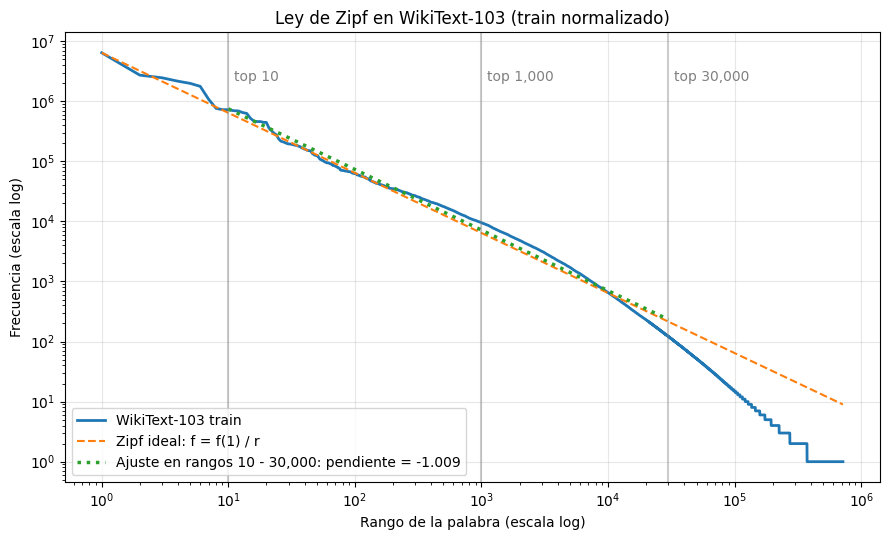

In [14]:
def pendiente_zipf(inicio, fin):
    """Pendiente en log-log entre dos rangos, con puntos espaciados logarítmicamente."""
    # Sin el muestreo logarítmico, los cientos de miles de palabras raras dominarían el ajuste
    indices = np.unique(np.geomspace(inicio, fin, 200).astype(int)) - 1
    pendiente, intercepto = np.polyfit(np.log10(rangos[indices]), np.log10(conteos_ordenados[indices]), 1)
    return pendiente, intercepto


tramos = {"1 - 1,000": (1, 1_000), "1,000 - 30,000": (1_000, 30_000),
          f"30,000 - {len(rangos):,}": (30_000, len(rangos)), "10 - 30,000 (ajuste)": (10, 30_000)}
for nombre, (inicio, fin) in tramos.items():
    print(f"Pendiente en rangos {nombre}: {pendiente_zipf(inicio, fin)[0]:.3f}")

pendiente, intercepto = pendiente_zipf(10, 30_000)
rangos_ajuste = rangos[9:30_000]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(rangos, conteos_ordenados, linewidth=2, label="WikiText-103 train")
ax.loglog(rangos, conteos_ordenados[0] / rangos, "--", label="Zipf ideal: f = f(1) / r")
ax.loglog(rangos_ajuste, 10 ** intercepto * rangos_ajuste ** pendiente, ":", linewidth=2.5,
          label=f"Ajuste en rangos 10 - 30,000: pendiente = {pendiente:.3f}")
for k in (10, 1_000, 30_000):
    ax.axvline(k, color="gray", alpha=0.4)
    ax.text(k * 1.1, conteos_ordenados[0] / 3, f"top {k:,}", color="gray")
ax.set_title("Ley de Zipf en WikiText-103 (train normalizado)")
ax.set_xlabel("Rango de la palabra (escala log)")
ax.set_ylabel("Frecuencia (escala log)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "zipf.png", dpi=150)
plt.show()

In [15]:
cobertura_acumulada = np.cumsum(conteos_ordenados) / total_tokens * 100

pd.DataFrame({
    "palabras_mas_frecuentes": [10, 1_000, 30_000],
    "tokens_cubiertos": [int(np.sum(conteos_ordenados[:k])) for k in (10, 1_000, 30_000)],
    "cobertura_%": [round(cobertura_acumulada[k - 1], 2) for k in (10, 1_000, 30_000)],
})

,palabras_mas_frecuentes,tokens_cubiertos,cobertura_%
0,10,20819540,24.61
1,1000,54155699,64.01
2,30000,80068586,94.64


**Construyan el vocabulario con un umbral de frecuencia mínima (min_count). ¿Qué tamaño de vocabulario y qué porcentaje de tokens desconocidos obtienen con al menos tres umbrales distintos?**

Sobre el train completo (84,607,547 tokens normalizados) se evaluaron seis umbrales. Con `min_count` de 3 se obtiene un vocabulario de 272,580 palabras y 0.643 % de tokens desconocidos, con 5 el vocabulario baja a 193,931 palabras con 0.958 %, con 10 a 127,797 con 1.469 % y con 100 a solo 33,804 palabras con 4.872 %. Es decir, al subir el umbral de 3 a 100 el vocabulario se reduce aproximadamente 8 veces mientras que los tokens desconocidos apenas pasan de 0.6 % a 4.9 %, ya que, como se observó con la ley de Zipf, las palabras raras son muchas pero representan una fracción muy pequeña del texto. No obstante, el costo se refleja en los benchmarks, ya que con un umbral de 100 se pierden 132 de las 905 palabras de las analogías, mientras que con 5 solo se pierden 15.

Cabe mencionar que, por restricciones de cómputo, para el resto del laboratorio se trabaja con un subconjunto formado por los primeros 6,801 artículos completos de train, que suman 20,008,141 tokens normalizados. Sobre este subconjunto se utiliza un `min_count` de 5, el valor por defecto de Word2Vec en gensim, con el que se obtiene un vocabulario de 87,487 palabras, 1.725 % de tokens desconocidos y 857 de las 905 palabras de las analogías. Dado que el subconjunto es aproximadamente 4.2 veces más pequeño que el corpus completo, este umbral se comporta de forma equivalente a un `min_count` de 20 sobre todo train, que produce un vocabulario de tamaño similar (86,126 palabras). Como limitación, el subconjunto corresponde a los primeros artículos del dataset y no a una muestra aleatoria.

In [19]:
UMBRALES_MIN_COUNT = [3, 5, 10, 20, 50, 100]

# Palabras de los benchmarks de selección, para ver cuántas sobreviven a cada umbral
palabras_analogias = {palabra.lower() for linea in lineas_analogias if not linea.startswith(":")
                      for palabra in linea.split()}
palabras_wordsim = set(df_wordsim["palabra_1"].str.lower()) | set(df_wordsim["palabra_2"].str.lower())

filas = []
for min_count in UMBRALES_MIN_COUNT:
    vocabulario = {palabra for palabra, n in frecuencias.items() if n >= min_count}
    tokens_unk = sum(n for palabra, n in frecuencias.items() if n < min_count)
    filas.append({
        "min_count": min_count,
        "tamano_vocabulario": len(vocabulario),
        "tokens_unk": tokens_unk,
        "porcentaje_unk": round(100 * tokens_unk / total_tokens, 3),
        "palabras_analogias": f"{len(palabras_analogias & vocabulario)}/{len(palabras_analogias)}",
        "palabras_wordsim": f"{len(palabras_wordsim & vocabulario)}/{len(palabras_wordsim)}",
    })

pd.DataFrame(filas)

,min_count,tamano_vocabulario,tokens_unk,porcentaje_unk,palabras_analogias,palabras_wordsim
0,3,272580,544261,0.643,897/905,437/437
1,5,193931,810620,0.958,890/905,437/437
2,10,127797,1242541,1.469,880/905,437/437
3,20,86126,1809455,2.139,865/905,437/437
4,50,51349,2893023,3.419,823/905,435/437
5,100,33804,4121662,4.872,773/905,424/437


**Implementen el submuestreo (subsampling) de palabras frecuentes de Word2Vec. ¿Qué porcentaje de las apariciones de "the", "of" y "and" se descarta? ¿Por qué ayuda al entrenamiento?**

Con la fórmula de submuestreo de gensim y el umbral por defecto `t = 1e-3` se descarta el 87.20 % de las apariciones de "the", el 79.28 % de "of" y el 78.02 % de "and", lo cual se verificó de forma empírica sobre 100,000 líneas de train, y aunque solo 25 palabras se ven afectadas, se elimina el 22.18 % de los tokens del corpus. Esto ayuda al entrenamiento ya que estas palabras aportan muy poco al significado de las que las rodean: saber que "king" aparece junto a "the" no dice nada sobre "king", puesto que "the" acompaña a prácticamente cualquier sustantivo. Es por esto que, al descartarlas, los pares de entrenamiento se concentran en palabras con contenido y el entrenamiento es más rápido, sin eliminarlas del vocabulario como ocurriría al quitar las stopwords.

In [20]:
UMBRALES_SUBMUESTREO = [1e-3, 1e-4, 1e-5]
PALABRAS_FRECUENTES = ["the", "of", "and"]
N_LINEAS_PRUEBA = 100_000


def probabilidad_conservar(frecuencias, total, t):
    """Probabilidad de conservar cada palabra con la fórmula de submuestreo de Word2Vec (versión de gensim)."""
    umbral = t * total
    return {palabra: min(1.0, (np.sqrt(n / umbral) + 1) * umbral / n) for palabra, n in frecuencias.items()}


def submuestrear(tokens, prob_conservar, rng):
    """Descarta cada aparición de una palabra con probabilidad 1 - P(conservar)."""
    return [token for token in tokens if rng.random() < prob_conservar.get(token, 1.0)]


filas = []
for t in UMBRALES_SUBMUESTREO:
    prob = probabilidad_conservar(frecuencias, total_tokens, t)
    fila = {"t": f"{t:.0e}"}
    for palabra in PALABRAS_FRECUENTES:
        fila[f"descarte_{palabra}_%"] = round(100 * (1 - prob[palabra]), 2)
    fila["descarte_total_%"] = round(100 * sum(n * (1 - prob[p]) for p, n in frecuencias.items()) / total_tokens, 2)
    fila["palabras_afectadas"] = sum(p < 1 for p in prob.values())
    filas.append(fila)
tabla_submuestreo = pd.DataFrame(filas)

# Verificación empírica de la implementación con t = 1e-3 en una muestra de train
rng = np.random.default_rng(SEED)
prob = probabilidad_conservar(frecuencias, total_tokens, 1e-3)
antes, despues = Counter(), Counter()
for linea in corpus["train"][:N_LINEAS_PRUEBA]["text"]:
    tokens = tokenizar(limpiar_wikitext(linea))
    antes.update(tokens)
    despues.update(submuestrear(tokens, prob, rng))
for palabra in PALABRAS_FRECUENTES:
    print(f"Descarte empírico de '{palabra}' con t = 1e-3: {100 * (1 - despues[palabra] / antes[palabra]):.2f} %")
print(f"Tokens de la muestra: {sum(antes.values()):,} -> {sum(despues.values()):,}")

tabla_submuestreo

Descarte empírico de 'the' con t = 1e-3: 87.20 %
Descarte empírico de 'of' con t = 1e-3: 79.29 %
Descarte empírico de 'and' con t = 1e-3: 77.99 %
Tokens de la muestra: 4,611,537 -> 3,588,776


,t,descarte_the_%,descarte_of_%,descarte_and_%,descarte_total_%,palabras_afectadas
0,1e-03,87.20,79.28,78.02,22.18,25
1,1e-04,96.24,94.12,93.79,39.19,373
2,1e-05,98.84,98.21,98.11,63.05,4031


## **Pipeline de preprocesamiento**

Con las decisiones anteriores se construye el pipeline completo sobre el subconjunto de entrenamiento: texto crudo -> `limpiar_wikitext` -> `tokenizar` -> vocabulario con `min_count` -> IDs. El corpus se guarda como un arreglo de IDs junto con el inicio de cada oración (`offsets`), de tal forma que las ventanas de contexto no crucen de un párrafo a otro.

In [23]:
RUTA_IDS = DIR_DATOS / "subconjunto_ids.npy"
RUTA_OFFSETS = DIR_DATOS / "subconjunto_offsets.npy"
RUTA_VOCABULARIO = DIR_DATOS / "vocabulario.json"
TOKENS_ESPECIALES = ["<pad>", "<unk>"]
ID_PAD, ID_UNK = 0, 1


def construir_subconjunto(lineas, tokens_minimos):
    """Tokeniza artículos completos de train hasta alcanzar el mínimo de tokens normalizados."""
    oraciones, total, articulos = [], 0, 0
    for i, linea in enumerate(lineas):
        es_titulo = (PATRON_TITULO.match(linea.rstrip("\n"))
                     and (i == 0 or lineas[i - 1] == "") and (i == len(lineas) - 1 or lineas[i + 1] == ""))
        if es_titulo:
            if total >= tokens_minimos:
                break
            articulos += 1
        tokens = tokenizar(limpiar_wikitext(linea))
        if tokens:
            oraciones.append(tokens)
            total += len(tokens)
    return oraciones, articulos


def construir_vocabulario(oraciones, min_count):
    """Vocabulario ordenado por frecuencia, con <pad> y <unk> al inicio."""
    conteo = Counter(token for oracion in oraciones for token in oracion)
    palabras = [palabra for palabra, n in conteo.most_common() if n >= min_count]
    conteos = [0, sum(n for n in conteo.values() if n < min_count)] + [conteo[p] for p in palabras]
    return TOKENS_ESPECIALES + palabras, conteos


if RUTA_IDS.exists() and RUTA_OFFSETS.exists() and RUTA_VOCABULARIO.exists():
    ids_corpus = np.load(RUTA_IDS)
    offsets = np.load(RUTA_OFFSETS)
    info_vocabulario = json.loads(RUTA_VOCABULARIO.read_text(encoding="utf-8"))
else:
    inicio = time.time()
    oraciones, n_articulos = construir_subconjunto(list(corpus["train"]["text"]), TOKENS_SUBCONJUNTO)
    itos, conteos = construir_vocabulario(oraciones, MIN_COUNT)
    stoi = {palabra: i for i, palabra in enumerate(itos)}
    ids_corpus = np.fromiter((stoi.get(t, ID_UNK) for oracion in oraciones for t in oracion), dtype=np.int32)
    offsets = np.cumsum([0] + [len(oracion) for oracion in oraciones], dtype=np.int64)
    info_vocabulario = {"itos": itos, "conteos": conteos, "articulos": n_articulos, "min_count": MIN_COUNT}
    np.save(RUTA_IDS, ids_corpus)
    np.save(RUTA_OFFSETS, offsets)
    RUTA_VOCABULARIO.write_text(json.dumps(info_vocabulario, ensure_ascii=False), encoding="utf-8")
    del oraciones
    print(f"Tiempo de construcción: {time.time() - inicio:.1f} s")

itos = info_vocabulario["itos"]
stoi = {palabra: i for i, palabra in enumerate(itos)}
conteos_vocabulario = np.array(info_vocabulario["conteos"], dtype=np.int64)

print(f"Artículos del subconjunto: {info_vocabulario['articulos']:,}")
print(f"Líneas (oraciones) con texto: {len(offsets) - 1:,}")
print(f"Tokens: {len(ids_corpus):,}")
print(f"Vocabulario con min_count = {MIN_COUNT}: {len(itos):,} (incluye {TOKENS_ESPECIALES})")
print(f"Tokens <unk>: {conteos_vocabulario[ID_UNK]:,} ({100 * conteos_vocabulario[ID_UNK] / len(ids_corpus):.3f} %)")
print(f"Ejemplo texto -> IDs: {itos[ids_corpus[0]]!r} -> {ids_corpus[0]}, primeras 10 IDs: {ids_corpus[:10].tolist()}")

Tiempo de construcción: 21.1 s
Artículos del subconjunto: 6,801
Líneas (oraciones) con texto: 203,995
Tokens: 20,008,141
Vocabulario con min_count = 5: 87,489 (incluye ['<pad>', '<unk>'])
Tokens <unk>: 345,198 (1.725 %)
Ejemplo texto -> IDs: 'senjō' -> 65686, primeras 10 IDs: [65686, 73, 20564, 156, 38088, 6424, 479, 1, 6294, 20564]


**Finalmente, generen los pares (palabra central, contexto) para skip-gram con una ventana de contexto y reporten cuántos pares de entrenamiento produce el corpus por epoch, antes y después del submuestreo.**

Los pares se generan con la función `generar_pares` utilizando una ventana de 5 palabras a cada lado, sin cruzar de un párrafo a otro y excluyendo los tokens `<unk>`, de la misma forma en que lo hace gensim. Por ejemplo, en la primera oración del subconjunto y con ventana de 2, la palabra "valkyria" genera cuatro pares, uno con cada una de las dos palabras anteriores y de las dos siguientes, como ("valkyria", "no"), ("valkyria", "3") y ("valkyria", "unrecorded"). Sobre el subconjunto de 19,662,943 tokens dentro del vocabulario, el corpus produce 190,611,304 pares por epoch antes del submuestreo, mientras que después de aplicarlo con `t = 1e-3` quedan 15,207,496 tokens y 146,067,686 pares, es decir, 23.37 % menos pares por epoch. Cabe mencionar que este conteo corresponde a una ventana fija, por lo que con la ventana dinámica que utiliza gensim por defecto el número real de pares sería menor.

In [24]:
def generar_pares(ids, ventana):
    """Genera los pares (central, contexto) de skip-gram de una oración con ventana fija."""
    pares = []
    for i, central in enumerate(ids):
        for j in range(max(0, i - ventana), min(len(ids), i + ventana + 1)):
            if j != i:
                pares.append((central, ids[j]))
    return pares


def contar_pares(longitudes, ventana):
    """Número exacto de pares con ventana fija para oraciones de las longitudes dadas."""
    n = longitudes.astype(np.int64)
    por_lado = np.where(n - 1 <= ventana, n * (n - 1) // 2,
                        ventana * (ventana + 1) // 2 + (n - 1 - ventana) * ventana)
    return int(2 * por_lado.sum())


def oraciones_filtradas(mascara):
    """Longitud de cada oración contando solo los tokens que cumplen la máscara."""
    return np.add.reduceat(mascara.astype(np.int64), offsets[:-1])


ejemplo = ids_corpus[offsets[0]:offsets[0] + 6].tolist()
print(f"Oración de ejemplo: {[itos[i] for i in ejemplo]}")
print(f"Pares con ventana 2: {[(itos[a], itos[b]) for a, b in generar_pares(ejemplo, 2)]}")

# Verificación de que el conteo con fórmula coincide con generar los pares uno por uno
n_verificacion = 1_000
pares_generados = sum(len(generar_pares(ids_corpus[offsets[k]:offsets[k + 1]].tolist(), VENTANA))
                      for k in range(n_verificacion))
pares_formula = contar_pares(np.diff(offsets[:n_verificacion + 1]), VENTANA)
print(f"Verificación en {n_verificacion:,} oraciones: generados = {pares_generados:,}, fórmula = {pares_formula:,}")

Oración de ejemplo: ['senjō', 'no', 'valkyria', '3', 'unrecorded', 'chronicles']
Pares con ventana 2: [('senjō', 'no'), ('senjō', 'valkyria'), ('no', 'senjō'), ('no', 'valkyria'), ('no', '3'), ('valkyria', 'senjō'), ('valkyria', 'no'), ('valkyria', '3'), ('valkyria', 'unrecorded'), ('3', 'no'), ('3', 'valkyria'), ('3', 'unrecorded'), ('3', 'chronicles'), ('unrecorded', 'valkyria'), ('unrecorded', '3'), ('unrecorded', 'chronicles'), ('chronicles', '3'), ('chronicles', 'unrecorded')]
Verificación en 1,000 oraciones: generados = 1,016,702, fórmula = 1,016,702


In [25]:
# Igual que gensim, las palabras bajo min_count (<unk>) no participan en los pares
total_vocabulario = conteos_vocabulario[len(TOKENS_ESPECIALES):].sum()
umbral = UMBRAL_SUBMUESTREO * total_vocabulario
frecuencia = np.maximum(conteos_vocabulario, 1)
prob_conservar_ids = np.minimum(1.0, (np.sqrt(frecuencia / umbral) + 1) * umbral / frecuencia)
prob_conservar_ids[:len(TOKENS_ESPECIALES)] = 0.0

mascara_vocabulario = ids_corpus != ID_UNK
rng = np.random.default_rng(SEED)
mascara_submuestreo = mascara_vocabulario & (rng.random(len(ids_corpus)) < prob_conservar_ids[ids_corpus])

escenarios = {
    "Antes del submuestreo (sin <unk>)": mascara_vocabulario,
    f"Después del submuestreo (t = {UMBRAL_SUBMUESTREO:.0e})": mascara_submuestreo,
}
filas = []
for nombre, mascara in escenarios.items():
    pares = contar_pares(oraciones_filtradas(mascara), VENTANA)
    filas.append({"escenario": nombre, "tokens": int(mascara.sum()), "pares_por_epoch": pares,
                  "pares_por_token": round(pares / mascara.sum(), 2)})
tabla_pares = pd.DataFrame(filas)
tabla_pares["reduccion_pares_%"] = (100 * (1 - tabla_pares["pares_por_epoch"] / tabla_pares["pares_por_epoch"].iloc[0])).round(2)
print(f"Ventana de contexto: {VENTANA}")
tabla_pares.style.format({"tokens": "{:,}", "pares_por_epoch": "{:,}"})

Ventana de contexto: 5


,escenario,tokens,pares_por_epoch,pares_por_token,reduccion_pares_%
0,Antes del submuestreo (sin ),"19,662,943","190,611,304",9.690000,0.000000
1,Después del submuestreo (t = 1e-03),"15,207,496","146,067,686",9.600000,23.370000


---
# **3. Investigación: embeddings en PyTorch y gensim**

Los embeddings son representaciones numéricas de palabras que permiten que un programa compare palabras y reconozca cuáles aparecen en contextos parecidos.

**nn.Embedding (num_embeddings, embedding_dim, padding_idx, sparse) y nn.Embedding.from_pretrained (freeze)**

`nn.Embedding` es una capa de PyTorch que asigna un vector a cada palabra según su identificador, donde `num_embeddings` indica cuántas palabras puede guardar y `embedding_dim` el tamaño de cada vector. `padding_idx` reserva una posición para rellenar textos cortos y evita que ese vector cambie durante el entrenamiento, mientras que `sparse=True` actualiza solo los vectores utilizados si se usa un optimizador compatible. En nuestro SGNS se usaron dos capas `nn.Embedding` de 87,489 x 300 (`entrada` y `salida`), sin `padding_idx` ni `sparse`, ya que se entrenaron con Adam denso. Por su parte, `from_pretrained` crea la capa a partir de vectores ya entrenados: con `freeze=True` los vectores quedan fijos y con `freeze=False` pueden seguir ajustándose, lo cual corresponde a las variantes congelada y con fine-tuning del clasificador de AG News.

**nn.EmbeddingBag y sus modos de agregación (mean, sum, max) usando offsets**

`nn.EmbeddingBag` reúne los vectores de varias palabras en uno solo: con `mode="mean"` calcula el promedio, con `mode="sum"` los suma y con `mode="max"` toma el valor más alto de cada posición. Cuando varios documentos se concatenan en una sola lista de identificadores, `offsets` indica dónde comienza cada uno, evitando tener que rellenarlos a la misma longitud. En el clasificador de AG News se utilizó con `mode="mean"`, de tal forma que cada noticia queda representada por el promedio de los vectores de sus palabras.

**Guardar, cargar y evaluar en PyTorch**

`torch.save` guarda los valores aprendidos y `torch.load` permite recuperarlos, lo cual se usó para conservar los pesos de la mejor epoch de cada clasificador y evaluarlos en test. Para comparar vectores, en lugar de `cosine_similarity` se calculó la similitud coseno como el producto punto entre vectores normalizados, ya que permite comparar una palabra contra todo el vocabulario en una sola operación.

**Word2Vec de gensim**

`Word2Vec` entrena vectores a partir de oraciones: `sentences` contiene los textos separados en palabras, `vector_size` define el tamaño del vector, `window` cuántas palabras cercanas se consideran, `min_count` excluye las poco frecuentes, `epochs` cuántas veces se recorren los textos y `sg` elige entre CBOW (0) y skip-gram (1). En nuestro caso se usó `sg=1` con negative sampling (`hs=0`, `negative=5`), `vector_size=300`, `window=5`, `sample=1e-3`, `min_count=5` y 5 epochs, igual que la mejor configuración de SGNS.

**Word2Vec.save y Word2Vec.load**

Guardan y recuperan el modelo completo, incluyendo el estado necesario para continuar el entrenamiento más adelante. Dado que no se iba a continuar entrenando, en este laboratorio únicamente se guardaron los vectores con `model.wv.save`, lo cual ocupa menos espacio.

**KeyedVectors**

Contiene los vectores entrenados, disponibles en `model.wv`, y permite consultarlos sin el resto del modelo. `most_similar` y `similarity` buscan palabras relacionadas, mientras que `evaluate_word_pairs` y `evaluate_word_analogies` comparan los resultados con pares valorados por personas y con analogías, respectivamente. GloVe se cargó directamente como `KeyedVectors` con `gensim.downloader`, y nuestros vectores de SGNS se convirtieron a este formato para usar las mismas evaluaciones. Cabe mencionar que `KeyedVectors` guarda en caché las normas de los vectores, por lo que al evaluar durante el entrenamiento es necesario recalcularlas con `fill_norms(force=True)`.

**Diferencia entre CBOW y skip-gram**

CBOW observa las palabras cercanas para intentar adivinar la palabra central, mientras que skip-gram hace lo contrario: parte de la palabra central e intenta predecir las palabras que la rodean. En este laboratorio se utilizó skip-gram tanto en nuestra implementación como en gensim.

**Por qué Word2Vec usa dos matrices (W de entrada y W' de salida) y cuál se conserva**

W es la matriz de entrada, que representa a cada palabra cuando es la palabra central, y W' es la matriz de salida, que la representa cuando aparece como contexto y se usa para predecir. Se usan dos matrices porque una misma palabra cumple dos papeles distintos en el entrenamiento. Al terminar, normalmente se conserva W como los embeddings: en nuestro SGNS corresponde a la capa `entrada` y en gensim a `model.wv`.

**Diferencia entre Word2Vec (predictivo) y GloVe (basado en conteos de co-ocurrencia)**

Word2Vec aprende intentando predecir palabras según su contexto, recorriendo el texto ventana por ventana, por lo que se considera predictivo. GloVe, en cambio, primero cuenta cuántas veces aparecen juntas las palabras en todo el corpus y construye una matriz global de co-ocurrencias, que luego factoriza para obtener los vectores. Ambos producen vectores con propiedades similares, pero siguen caminos distintos.

**Referencias**

- EmbeddingBag - PyTorch 2.14 documentation. (n.d.). *PyTorch documentation*. Retrieved October 3, 2026, from https://docs.pytorch.org/docs/2.14/generated/torch.nn.EmbeddingBag.html
- Embedding - PyTorch 2.14 documentation. (n.d.). *PyTorch documentation*. Retrieved October 3, 2026, from https://docs.pytorch.org/docs/2.14/generated/torch.nn.Embedding.html
- GloVe: Global Vectors for Word Representation. (n.d.). *Stanford NLP Group*. Retrieved October 3, 2026, from https://nlp.stanford.edu/projects/glove/
- Inkawhich, M. (2018, August 29). *Saving and Loading Models*. PyTorch. Retrieved October 3, 2026, from https://docs.pytorch.org/tutorials/beginner/saving_loading_models
- Store and query word vectors. (n.d.). *models.keyedvectors - gensim*. Retrieved October 3, 2026, from https://radimrehurek.com/gensim/models/keyedvectors.html
- Word2vec embeddings. (n.d.). *models.word2vec - gensim*. Retrieved October 3, 2026, from https://radimrehurek.com/gensim/models/word2vec.html

---
# **4. Construcción y entrenamiento de los embeddings**

En esta sección se obtienen los tres conjuntos de embeddings: un skip-gram con negative sampling (SGNS) implementado desde cero en PyTorch, un Word2Vec de gensim entrenado con el mismo corpus, vocabulario e hiperparámetros equivalentes a la mejor configuración de SGNS, y GloVe preentrenado usado tal cual. Todos los modelos entrenados utilizan el subconjunto de 20M tokens y el vocabulario de la sección 2.

## **Skip-gram con negative sampling (PyTorch)**

En cada epoch se aplica un submuestreo nuevo y se generan los pares con ventana dinámica (cada palabra central usa una ventana aleatoria entre 1 y la ventana máxima), tal como lo hace gensim. Por cada par real se muestrean `negativos` palabras de una distribución proporcional a frecuencia^0.75. El modelo tiene dos tablas `nn.Embedding`: `entrada` (W) y `salida` (W'), y al final se conserva W.

In [28]:
import torch.nn.functional as F

oracion_de_token = np.repeat(np.arange(len(offsets) - 1), np.diff(offsets))

# Tabla de muestreo de negativos con probabilidad proporcional a frecuencia^0.75, como en Word2Vec
peso_unigrama = conteos_vocabulario.astype(np.float64) ** 0.75
peso_unigrama[:len(TOKENS_ESPECIALES)] = 0
rng_tabla = np.random.default_rng(SEED)
tabla_negativos = torch.from_numpy(
    np.searchsorted(np.cumsum(peso_unigrama / peso_unigrama.sum()), rng_tabla.random(10_000_000))
).to(DEVICE)


def generar_pares_epoch(n_tokens, ventana, umbral, rng):
    """Submuestrea el corpus y genera los pares de una epoch con ventana dinámica, igual que gensim."""
    ids, oraciones = ids_corpus[:n_tokens], oracion_de_token[:n_tokens]
    conteos = np.bincount(ids, minlength=len(itos))
    umbral_absoluto = umbral * conteos[len(TOKENS_ESPECIALES):].sum()
    frecuencia = np.maximum(conteos, 1)
    prob = np.minimum(1.0, (np.sqrt(frecuencia / umbral_absoluto) + 1) * umbral_absoluto / frecuencia)
    prob[:len(TOKENS_ESPECIALES)] = 0.0  # <unk> nunca participa

    mascara = rng.random(n_tokens) < prob[ids]
    tokens, oracion = ids[mascara], oraciones[mascara]
    # Cada palabra central usa una ventana aleatoria entre 1 y la ventana máxima
    ventana_efectiva = rng.integers(1, ventana + 1, size=len(tokens))
    centros, contextos = [], []
    for d in range(1, ventana + 1):
        i = np.arange(len(tokens) - d)
        j = i + d
        misma_oracion = oracion[i] == oracion[j]
        hacia_derecha = misma_oracion & (ventana_efectiva[i] >= d)
        hacia_izquierda = misma_oracion & (ventana_efectiva[j] >= d)
        centros += [tokens[i[hacia_derecha]], tokens[j[hacia_izquierda]]]
        contextos += [tokens[j[hacia_derecha]], tokens[i[hacia_izquierda]]]
    centros, contextos = np.concatenate(centros), np.concatenate(contextos)
    orden = rng.permutation(len(centros))
    return torch.from_numpy(centros[orden]), torch.from_numpy(contextos[orden])


class SkipGramNS(nn.Module):
    """Skip-gram con negative sampling: tabla de entrada W y tabla de salida W'."""

    def __init__(self, n_palabras, dim):
        super().__init__()
        self.entrada = nn.Embedding(n_palabras, dim)
        self.salida = nn.Embedding(n_palabras, dim)
        # Misma inicialización que word2vec: W pequeña y aleatoria, W' en ceros
        nn.init.uniform_(self.entrada.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.salida.weight)

    def forward(self, centros, contextos, negativos):
        v = self.entrada(centros)
        positivo = F.logsigmoid((v * self.salida(contextos)).sum(dim=1))
        negativo = F.logsigmoid(-torch.bmm(self.salida(negativos), v.unsqueeze(2)).squeeze(2)).sum(dim=1)
        return -(positivo + negativo).mean()


centros_prueba, contextos_prueba = generar_pares_epoch(len(ids_corpus), VENTANA, UMBRAL_SUBMUESTREO, np.random.default_rng(SEED))
print(f"Pares de una epoch con ventana dinámica: {len(centros_prueba):,}")
print(f"Ejemplos: {[(itos[c], itos[x]) for c, x in zip(centros_prueba[:5].tolist(), contextos_prueba[:5].tolist())]}")
modelo_prueba = SkipGramNS(len(itos), DIM_BASE)
print(f"Parámetros con dim = {DIM_BASE}: {sum(p.numel() for p in modelo_prueba.parameters()):,}")
del centros_prueba, contextos_prueba, modelo_prueba

Pares de una epoch con ventana dinámica: 88,439,229
Ejemplos: [('street', 'canal'), ('he', 'his'), ('scheduled', 'september'), ('salford', 'industrialisation'), ('1942', 'contained')]
Parámetros con dim = 100: 17,497,800


Al final de cada epoch se evalúan las analogías de `questions-words.txt` restringidas a las 30,000 palabras más frecuentes del modelo (semánticas, sintácticas y total), la correlación de Spearman en WordSim-353 y los 5 vecinos más cercanos de las palabras de control. SimLex-999 no se usa aquí, ya que se reserva para la evaluación final.

In [29]:
from gensim.models import KeyedVectors


def a_keyedvectors(palabras, vectores):
    """Envuelve una matriz de embeddings en KeyedVectors para usar las evaluaciones de gensim."""
    kv = KeyedVectors(vectores.shape[1])
    kv.add_vectors(palabras, vectores)
    return kv


def evaluar_embeddings(kv):
    """Analogías (semánticas, sintácticas y total), Spearman en WordSim-353 y vecinos de control."""
    _, secciones = kv.evaluate_word_analogies(analogias, restrict_vocab=VOCAB_EVALUACION)
    conteo = {"semanticas": [0, 0], "sintacticas": [0, 0]}
    for seccion in secciones[:-1]:
        tipo = "sintacticas" if seccion["section"].startswith("gram") else "semanticas"
        conteo[tipo][0] += len(seccion["correct"])
        conteo[tipo][1] += len(seccion["correct"]) + len(seccion["incorrect"])
    total = secciones[-1]
    evaluadas = len(total["correct"]) + len(total["incorrect"])
    return {
        "analogias_semanticas": conteo["semanticas"][0] / conteo["semanticas"][1],
        "analogias_sintacticas": conteo["sintacticas"][0] / conteo["sintacticas"][1],
        "analogias_total": len(total["correct"]) / evaluadas,
        "analogias_evaluadas": evaluadas,
        "wordsim_spearman": float(kv.evaluate_word_pairs(wordsim)[1][0]),
        "vecinos": {p: [w for w, _ in kv.most_similar(p, topn=5)] if p in kv else [] for p in PALABRAS_CONTROL},
    }


def sincronizar():
    """Espera a que la GPU termine para medir tiempos reales."""
    if DEVICE.type == "mps":
        torch.mps.synchronize()


def memoria_gpu():
    """Memoria asignada en la GPU en bytes (MPS no tiene max_memory_allocated)."""
    return torch.mps.current_allocated_memory() if DEVICE.type == "mps" else 0

La función de entrenamiento es reanudable: cada iteración guarda su registro (configuración, historial por epoch, tiempos y memoria) en `resultados/iteraciones_sgns/` y la matriz W en `modelos/`. Si una iteración ya existe, se carga en lugar de reentrenarse.

In [30]:
DIR_ITERACIONES = DIR_RESULTADOS / "iteraciones_sgns"
DIR_ITERACIONES.mkdir(exist_ok=True)


def entrenar_sgns(nombre, config):
    """Entrena una iteración de SGNS y guarda su registro; si ya existe, solo lo carga."""
    ruta_registro = DIR_ITERACIONES / f"{nombre}.json"
    ruta_pesos = DIR_MODELOS / f"sgns_{nombre}.npy"
    if ruta_registro.exists() and ruta_pesos.exists():
        print(f"[{nombre}] ya entrenada, se carga del registro")
        return json.loads(ruta_registro.read_text(encoding="utf-8"))

    fijar_semilla()
    rng = np.random.default_rng(SEED)
    # La fracción del corpus se toma en oraciones completas
    n_tokens = int(offsets[round(config["fraccion_corpus"] * (len(offsets) - 1))])
    tokens_corpus = int(np.count_nonzero(ids_corpus[:n_tokens] != ID_UNK))
    modelo = SkipGramNS(len(itos), config["dim"]).to(DEVICE)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=config["learning_rate"])
    print(f"[{nombre}] {config} | tokens: {tokens_corpus:,}")

    historial, memoria_pico = [], memoria_gpu()
    inicio_total = time.time()
    for epoch in range(1, config["epochs"] + 1):
        inicio = time.time()
        centros, contextos = generar_pares_epoch(n_tokens, config["ventana"], config["umbral_submuestreo"], rng)
        suma_perdida = torch.zeros((), device=DEVICE)
        perdidas_cada_n = []
        n_pasos = 0
        for k in range(0, len(centros), config["batch_size"]):
            c = centros[k:k + config["batch_size"]].to(DEVICE)
            x = contextos[k:k + config["batch_size"]].to(DEVICE)
            negativos = tabla_negativos[torch.randint(len(tabla_negativos), (len(c), config["negativos"]), device=DEVICE)]
            perdida = modelo(c, x, negativos)
            optimizador.zero_grad(set_to_none=True)
            perdida.backward()
            optimizador.step()
            suma_perdida += perdida.detach()
            if n_pasos % PASOS_REGISTRO == 0:
                perdidas_cada_n.append(perdida.item())
                memoria_pico = max(memoria_pico, memoria_gpu())
            n_pasos += 1
        sincronizar()
        tiempo_epoch = time.time() - inicio

        inicio_evaluacion = time.time()
        vectores = modelo.entrada.weight.detach().cpu().numpy()
        metricas = evaluar_embeddings(a_keyedvectors(itos[len(TOKENS_ESPECIALES):], vectores[len(TOKENS_ESPECIALES):]))
        historial.append({
            "epoch": epoch, "perdida": suma_perdida.item() / n_pasos, "perdidas_cada_n_pasos": perdidas_cada_n,
            "pares": len(centros), "pasos": n_pasos, "tiempo_epoch_s": tiempo_epoch,
            "tiempo_evaluacion_s": time.time() - inicio_evaluacion, **metricas,
        })
        print(f"[{nombre}] epoch {epoch}: pérdida {historial[-1]['perdida']:.4f}, "
              f"analogías {metricas['analogias_total']:.4f} (sem {metricas['analogias_semanticas']:.4f}, "
              f"sin {metricas['analogias_sintacticas']:.4f}), WordSim {metricas['wordsim_spearman']:.4f}, "
              f"{tiempo_epoch:.1f} s")
        del centros, contextos

    registro = {
        "nombre": nombre, "config": config, "tokens_corpus": tokens_corpus, "vocabulario": len(itos),
        "parametros": sum(p.numel() for p in modelo.parameters()), "historial": historial,
        "tiempo_total_s": time.time() - inicio_total,
        "tiempo_entrenamiento_s": sum(h["tiempo_epoch_s"] for h in historial),
        "memoria_pico_gb": memoria_pico / 1e9, "dispositivo": str(DEVICE),
    }
    np.save(ruta_pesos, vectores)
    ruta_registro.write_text(json.dumps(registro, ensure_ascii=False, indent=1), encoding="utf-8")
    del modelo, optimizador
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    return registro

## **Iteraciones de SGNS**

Cada iteración cambia un único hiperparámetro respecto a la configuración base (dim 100, ventana 5, 5 negativos, submuestreo 1e-3, `min_count` 5, 100 % del subconjunto, 5 epochs, Adam con learning rate 2e-3 y batch de 32,768 pares). El tiempo estimado total es de aproximadamente 1.5 horas en MPS; si se interrumpe, al volver a ejecutar la celda continúa desde la siguiente iteración pendiente.

In [31]:
CONFIG_BASE = {
    "dim": DIM_BASE, "ventana": VENTANA, "negativos": NEGATIVOS, "umbral_submuestreo": UMBRAL_SUBMUESTREO,
    "min_count": MIN_COUNT, "fraccion_corpus": 1.0, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
}
# Cada iteración cambia un solo hiperparámetro respecto a la base
ITERACIONES = {
    "base": {},
    "dim_50": {"dim": 50},
    "dim_300": {"dim": 300},
    "corpus_25": {"fraccion_corpus": 0.25},
    "corpus_50": {"fraccion_corpus": 0.5},
    "ventana_2": {"ventana": 2},
    "ventana_10": {"ventana": 10},
    "negativos_15": {"negativos": 15},
    "submuestreo_1e-4": {"umbral_submuestreo": 1e-4},
}

registro_sgns = {nombre: entrenar_sgns(nombre, {**CONFIG_BASE, **cambios}) for nombre, cambios in ITERACIONES.items()}

[base] {'dim': 100, 'ventana': 5, 'negativos': 5, 'umbral_submuestreo': 0.001, 'min_count': 5, 'fraccion_corpus': 1.0, 'epochs': 5, 'batch_size': 32768, 'learning_rate': 0.002} | tokens: 19,662,943
[base] epoch 1: pérdida 2.4541, analogías 0.1659 (sem 0.1142, sin 0.1897), WordSim 0.5544, 96.5 s
[base] epoch 2: pérdida 2.2662, analogías 0.3050 (sem 0.1957, sin 0.3551), WordSim 0.6140, 98.1 s
[base] epoch 3: pérdida 2.2288, analogías 0.3559 (sem 0.2482, sin 0.4053), WordSim 0.6344, 98.1 s
[base] epoch 4: pérdida 2.2115, analogías 0.3784 (sem 0.2830, sin 0.4222), WordSim 0.6463, 99.1 s
[base] epoch 5: pérdida 2.2011, analogías 0.3866 (sem 0.3043, sin 0.4244), WordSim 0.6455, 99.5 s
[dim_50] {'dim': 50, 'ventana': 5, 'negativos': 5, 'umbral_submuestreo': 0.001, 'min_count': 5, 'fraccion_corpus': 1.0, 'epochs': 5, 'batch_size': 32768, 'learning_rate': 0.002} | tokens: 19,662,943
[dim_50] epoch 1: pérdida 2.5035, analogías 0.0936 (sem 0.0759, sin 0.1018), WordSim 0.5019, 55.8 s
[dim_50] epoc

In [32]:
filas = []
for nombre, r in registro_sgns.items():
    final = r["historial"][-1]
    filas.append({
        "iteracion": nombre, "dim": r["config"]["dim"], "ventana": r["config"]["ventana"],
        "negativos": r["config"]["negativos"], "submuestreo": r["config"]["umbral_submuestreo"],
        "tokens_corpus": r["tokens_corpus"], "perdida_final": round(final["perdida"], 4),
        "analogias_sem": round(final["analogias_semanticas"], 4), "analogias_sin": round(final["analogias_sintacticas"], 4),
        "analogias_total": round(final["analogias_total"], 4), "wordsim": round(final["wordsim_spearman"], 4),
        "tiempo_epoch_min": round(np.mean([h["tiempo_epoch_s"] for h in r["historial"]]) / 60, 2),
        "tiempo_total_min": round(r["tiempo_total_s"] / 60, 2), "memoria_pico_gb": round(r["memoria_pico_gb"], 2),
    })
tabla_iteraciones = pd.DataFrame(filas).set_index("iteracion")

# Selección por las métricas de validación (analogías y WordSim), nunca por SimLex
MEJOR_SGNS = tabla_iteraciones.sort_values(["analogias_total", "wordsim"], ascending=False).index[0]
print(f"Mejor iteración: {MEJOR_SGNS}")
tabla_iteraciones

Mejor iteración: dim_300


,dim,ventana,negativos,submuestreo,tokens_corpus,perdida_final,analogias_sem,analogias_sin,analogias_total,wordsim,tiempo_epoch_min,tiempo_total_min,memoria_pico_gb
iteracion,,,,,,,,,,,,,
base,100,5,5,0.0010,19662943,2.2011,0.3043,0.4244,0.3866,0.6455,1.64,8.51,0.37
dim_50,50,5,5,0.0010,19662943,2.2453,0.2057,0.3227,0.2859,0.6156,0.95,5.00,0.23
dim_300,300,5,5,0.0010,19662943,2.1290,0.4246,0.4808,0.4631,0.6836,4.46,23.43,0.94
corpus_25,100,5,5,0.0010,4875402,2.1848,0.0805,0.1616,0.1361,0.5069,0.38,2.29,0.37
corpus_50,100,5,5,0.0010,9855057,2.1839,0.1906,0.3121,0.2739,0.6199,0.77,4.18,0.37
ventana_2,100,2,5,0.0010,19662943,2.0527,0.2380,0.4078,0.3544,0.6086,0.75,4.11,0.37
ventana_10,100,10,5,0.0010,19662943,2.2710,0.3489,0.4178,0.3962,0.6560,2.84,14.56,0.37
negativos_15,100,5,15,0.0010,19662943,3.1368,0.3463,0.4627,0.4261,0.6195,3.65,18.66,0.37
submuestreo_1e-4,100,5,5,0.0001,19662943,2.1563,0.3191,0.4272,0.3932,0.6676,1.53,8.07,0.37


In [33]:
def vecinos_por_epoch(nombre):
    """Tabla con los 5 vecinos más cercanos de cada palabra de control al final de cada epoch."""
    historial = registro_sgns[nombre]["historial"]
    return pd.DataFrame({f"epoch {h['epoch']}": {p: ", ".join(v) for p, v in h["vecinos"].items()} for h in historial})


vecinos_por_epoch(MEJOR_SGNS)

,epoch 1,epoch 2,epoch 3,epoch 4,epoch 5
king,"kalachuri, henry, mbó, dagobert, pope","maíl, mbó, diarmait, murchad, æthelred","maíl, mbó, diarmait, queen, sennacherib","maíl, ballala, mbó, sennacherib, monarch","maíl, mbó, monarch, queen, diarmait"
france,"spain, italy, portugal, belgium, netherlands","spain, italy, portugal, netherlands, belgium","italy, spain, portugal, belgium, austria","spain, italy, germany, belgium, austria","spain, italy, germany, belgium, austria"
computer,"computers, desktop, software, multi-core, computing","computers, desktop, pdp-1, havok, software","computers, desktop, real-time, pdp-1, software","computers, software, desktop, multi-core, pdp-1","computers, multi-core, mainframe, software, real-time"
good,"bad, decent, craved, nice, wonderful","bad, excellent, poor, decent, nice","bad, excellent, better, poor, pretty","bad, excellent, poor, better, pretty","bad, excellent, better, poor, luck"
january,"february, december, november, march, july","february, december, march, november, july","february, december, march, october, july","february, march, december, november, october","february, december, march, october, november"
run,"pinch-hit, 76-yard, three-run, walk-off, inside-the-park","inside-the-park, runs, three-run, game-tying, running","runs, running, inside-the-park, ran, eighth-inning","runs, running, inside-the-park, eighth-inning, ran","running, runs, inside-the-park, ran, three-run"


**Grafiquen las curvas de pérdida y de accuracy de analogías por epoch de al menos 3 iteraciones. ¿Una pérdida más baja implica siempre mejores embeddings?**

No. Un embedding es la representación de una palabra como un vector denso, de tal forma que palabras que aparecen en contextos similares queden cerca en el espacio, mientras que la pérdida de SGNS mide únicamente qué tan bien el modelo distingue los pares (palabra central, contexto) reales de los pares formados con palabras negativas al azar, por lo que evalúa la tarea de entrenamiento y no la calidad del significado capturado. Esto se observa al contrastar las iteraciones: `corpus_25` obtuvo una pérdida de 2.185, menor a la de la base (2.201), pero solo 13.61 % de accuracy en analogías, ya que con 4.9M tokens el modelo aprende a separar los mismos pares sin capturar relaciones generales, y `ventana_2` alcanzó la pérdida más baja (2.053) al predecir únicamente vecinos inmediatos, pero su accuracy (35.44 %) quedó por debajo del de la base (38.66 %). En cambio, `negativos_15` tuvo la pérdida más alta (3.137) y el segundo mejor accuracy (42.61 %), aunque cabe mencionar que su pérdida suma 15 términos negativos en lugar de 5. Es por esto que la pérdida solo resulta útil para monitorear la convergencia dentro de una misma iteración, donde las curvas muestran que baja mientras el accuracy sube, pero no para comparar configuraciones distintas.

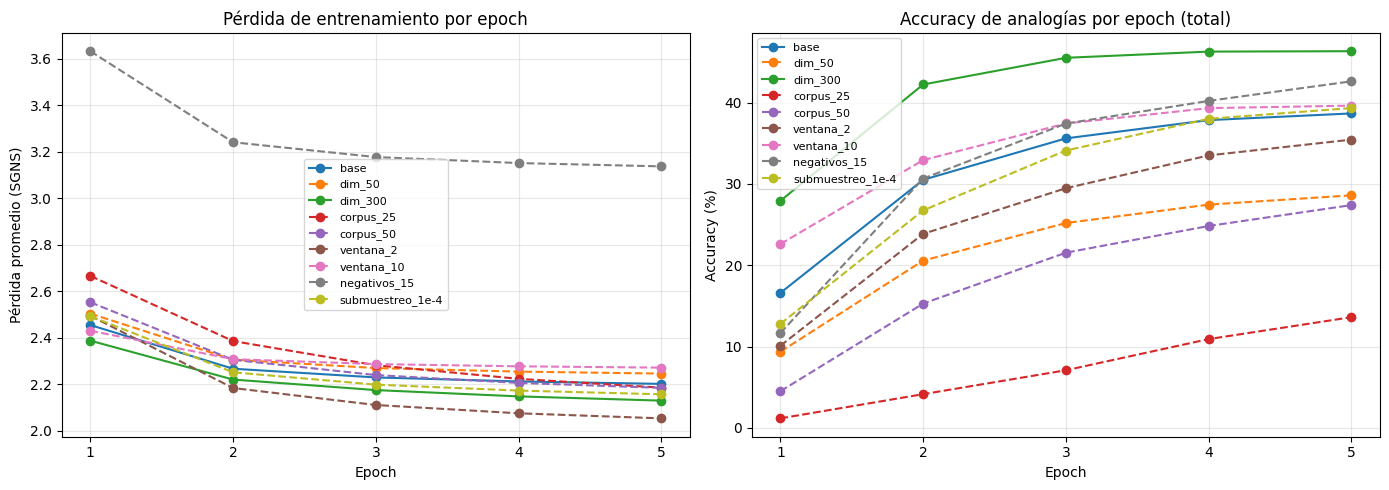

In [35]:
fig, (ax_perdida, ax_analogias) = plt.subplots(1, 2, figsize=(14, 5))
for nombre, r in registro_sgns.items():
    epochs = [h["epoch"] for h in r["historial"]]
    estilo = "-" if nombre in ("base", MEJOR_SGNS) else "--"
    ax_perdida.plot(epochs, [h["perdida"] for h in r["historial"]], estilo, marker="o", label=nombre)
    ax_analogias.plot(epochs, [100 * h["analogias_total"] for h in r["historial"]], estilo, marker="o", label=nombre)
ax_perdida.set_title("Pérdida de entrenamiento por epoch")
ax_perdida.set_xlabel("Epoch")
ax_perdida.set_ylabel("Pérdida promedio (SGNS)")
ax_analogias.set_title("Accuracy de analogías por epoch (total)")
ax_analogias.set_xlabel("Epoch")
ax_analogias.set_ylabel("Accuracy (%)")
for ax in (ax_perdida, ax_analogias):
    ax.set_xticks(range(1, EPOCHS + 1))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "curvas_sgns.png", dpi=150)
plt.show()

## **Word2Vec de gensim**

Como implementación de referencia se entrena `Word2Vec` de gensim en modo skip-gram (`sg=1`) con negative sampling, sobre exactamente las mismas oraciones del subconjunto y con los hiperparámetros de la mejor iteración de SGNS. Con `min_count` igual, gensim construye el mismo vocabulario de 87,487 palabras. La diferencia principal es el optimizador: gensim usa SGD par por par con un learning rate que decae linealmente de 0.025 a 0.0001 y corre en CPU, mientras que nuestro SGNS usa Adam en batches de 32,768 pares en MPS. Cabe mencionar que con Python 3.13 gensim imprime ocasionalmente el aviso `Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'`; no corresponde a una excepción real de Python y aparece aproximadamente una docena de veces por epoch, frente a cerca de 88M pares, por lo que su efecto es despreciable.

In [38]:
import os

from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

RUTA_GENSIM_KV = DIR_MODELOS / "gensim_word2vec.kv"
RUTA_GENSIM_REGISTRO = DIR_RESULTADOS / "gensim_word2vec.json"
config_mejor = registro_sgns[MEJOR_SGNS]["config"]


class RegistroPorEpoch(CallbackAny2Vec):
    """Registra pérdida, tiempo y métricas de evaluación al final de cada epoch de gensim."""

    def __init__(self):
        self.historial, self.epoch, self.perdida_acumulada = [], 0, 0.0
        self.inicio = time.time()

    def on_epoch_end(self, modelo):
        self.epoch += 1
        tiempo_epoch = time.time() - self.inicio
        # gensim reporta la pérdida acumulada, por lo que se resta la de la epoch anterior
        perdida_total = modelo.get_latest_training_loss()
        perdida_epoch, self.perdida_acumulada = perdida_total - self.perdida_acumulada, perdida_total
        # gensim guarda en caché las normas de los vectores; sin recalcularlas, most_similar usaría las de la epoch 1
        modelo.wv.fill_norms(force=True)
        metricas = evaluar_embeddings(modelo.wv)
        self.historial.append({"epoch": self.epoch, "perdida_gensim": perdida_epoch, "tiempo_epoch_s": tiempo_epoch, **metricas})
        print(f"[gensim] epoch {self.epoch}: analogías {metricas['analogias_total']:.4f} "
              f"(sem {metricas['analogias_semanticas']:.4f}, sin {metricas['analogias_sintacticas']:.4f}), "
              f"WordSim {metricas['wordsim_spearman']:.4f}, {tiempo_epoch:.1f} s")
        self.inicio = time.time()


if RUTA_GENSIM_KV.exists() and RUTA_GENSIM_REGISTRO.exists():
    vectores_gensim = KeyedVectors.load(str(RUTA_GENSIM_KV))
    registro_gensim = json.loads(RUTA_GENSIM_REGISTRO.read_text(encoding="utf-8"))
    print("Word2Vec de gensim ya entrenado, se carga del registro")
else:
    # Mismo corpus que SGNS: las oraciones del subconjunto sin los <unk>, que gensim descartaría igual
    oraciones_gensim = [[itos[i] for i in ids_corpus[a:b] if i != ID_UNK] for a, b in zip(offsets[:-1], offsets[1:])]
    callback = RegistroPorEpoch()
    inicio = time.time()
    modelo_gensim = Word2Vec(
        sentences=oraciones_gensim, sg=1, hs=0, vector_size=config_mejor["dim"], window=config_mejor["ventana"],
        negative=config_mejor["negativos"], sample=config_mejor["umbral_submuestreo"], min_count=config_mejor["min_count"],
        epochs=config_mejor["epochs"], workers=os.cpu_count(), seed=SEED, compute_loss=True, callbacks=[callback],
    )
    vectores_gensim = modelo_gensim.wv
    registro_gensim = {
        "config": {**config_mejor, "sg": 1, "alpha": modelo_gensim.alpha, "min_alpha": modelo_gensim.min_alpha,
                   "workers": os.cpu_count()},
        "tokens_corpus": modelo_gensim.corpus_total_words, "vocabulario": len(vectores_gensim),
        "historial": callback.historial, "tiempo_total_s": time.time() - inicio, "dispositivo": "cpu",
    }
    vectores_gensim.save(str(RUTA_GENSIM_KV))
    RUTA_GENSIM_REGISTRO.write_text(json.dumps(registro_gensim, ensure_ascii=False, indent=1), encoding="utf-8")
    del oraciones_gensim, modelo_gensim

print(f"Vocabulario gensim: {registro_gensim['vocabulario']:,} | SGNS: {len(itos) - len(TOKENS_ESPECIALES):,}")
print(f"Tokens del corpus: {registro_gensim['tokens_corpus']:,} | Tiempo total: {registro_gensim['tiempo_total_s'] / 60:.1f} min")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

[gensim] epoch 1: analogías 0.1234 (sem 0.0636, sin 0.1494), WordSim 0.5065, 24.9 s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

[gensim] epoch 2: analogías 0.2258 (sem 0.1289, sin 0.2680), WordSim 0.5804, 26.0 s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[gensim] epoch 3: analogías 0.3130 (sem 0.1818, sin 0.3701), WordSim 0.6229, 31.6 s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[gensim] epoch 4: analogías 0.3636 (sem 0.2266, sin 0.4232), WordSim 0.6389, 26.8 s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

[gensim] epoch 5: analogías 0.3939 (sem 0.2630, sin 0.4508), WordSim 0.6422, 30.3 s
Vocabulario gensim: 87,487 | SGNS: 87,487
Tokens del corpus: 19,662,943 | Tiempo total: 3.5 min


## **GloVe preentrenado**

GloVe (`glove-wiki-gigaword-100`) se utiliza tal cual, sin entrenamiento adicional, y se evalúa con las mismas métricas. Al final se resume el estado de los tres conjuntos de embeddings. Cabe mencionar que el número de analogías evaluadas difiere entre modelos, ya que cada uno usa sus propias 30,000 palabras más frecuentes; la comparación con un vocabulario compartido se realiza en la sección 5.

In [39]:
RUTA_GLOVE_REGISTRO = DIR_RESULTADOS / "glove.json"

# GloVe se usa tal cual: no se entrena, solo se evalúa con las mismas métricas
if RUTA_GLOVE_REGISTRO.exists():
    registro_glove = json.loads(RUTA_GLOVE_REGISTRO.read_text(encoding="utf-8"))
else:
    registro_glove = {
        "modelo": "glove-wiki-gigaword-100", "tokens_corpus": 6_000_000_000, "vocabulario": len(glove),
        "dim": glove.vector_size, **evaluar_embeddings(glove),
    }
    RUTA_GLOVE_REGISTRO.write_text(json.dumps(registro_glove, ensure_ascii=False, indent=1), encoding="utf-8")

# Vectores del mejor SGNS en formato KeyedVectors para las secciones siguientes
RUTA_SGNS_KV = DIR_MODELOS / "sgns_mejor.kv"
vectores_sgns = a_keyedvectors(itos[len(TOKENS_ESPECIALES):],
                               np.load(DIR_MODELOS / f"sgns_{MEJOR_SGNS}.npy")[len(TOKENS_ESPECIALES):])
vectores_sgns.save(str(RUTA_SGNS_KV))

final_sgns = registro_sgns[MEJOR_SGNS]["historial"][-1]
final_gensim = registro_gensim["historial"][-1]
resumen = {
    f"SGNS ({MEJOR_SGNS})": (registro_sgns[MEJOR_SGNS]["tokens_corpus"], len(vectores_sgns), vectores_sgns.vector_size, final_sgns),
    "Word2Vec gensim": (registro_gensim["tokens_corpus"], registro_gensim["vocabulario"], vectores_gensim.vector_size, final_gensim),
    "GloVe": (registro_glove["tokens_corpus"], registro_glove["vocabulario"], registro_glove["dim"], registro_glove),
}
tabla_tres_modelos = pd.DataFrame({
    nombre: {
        "tokens_corpus": f"{tokens:,}", "vocabulario": f"{vocab:,}", "dim": dim,
        "analogias_sem_%": round(100 * m["analogias_semanticas"], 2), "analogias_sin_%": round(100 * m["analogias_sintacticas"], 2),
        "analogias_total_%": round(100 * m["analogias_total"], 2), "analogias_evaluadas": m["analogias_evaluadas"],
        "wordsim_spearman": round(m["wordsim_spearman"], 4),
    }
    for nombre, (tokens, vocab, dim, m) in resumen.items()
}).T
tabla_tres_modelos

,tokens_corpus,vocabulario,dim,analogias_sem_%,analogias_sin_%,analogias_total_%,analogias_evaluadas,wordsim_spearman
SGNS (dim_300),"19,662,943","87,487",300,42.46,48.08,46.31,11801,0.6836
Word2Vec gensim,"19,662,943","87,487",300,26.3,45.08,39.39,11775,0.6422
GloVe,"6,000,000,000","400,000",100,65.54,65.45,65.49,14877,0.5327


## **Sinopsis de resultados**

Para evaluar los embeddings se utilizaron dos métricas. El accuracy de analogías mide el porcentaje de preguntas del tipo "a es a b como c es a d" en las que la palabra más cercana a `b - a + c` es exactamente `d`, y se separa en semánticas (conocimiento del mundo, como país-capital o relaciones familiares) y sintácticas (relaciones gramaticales, como plurales, comparativos o tiempos verbales). Por su parte, la correlación de Spearman en WordSim-353 mide qué tanto coincide el orden de similitud coseno del modelo con el orden que asignaron personas a 353 pares de palabras. Con la misma configuración (dimensión 300, ventana 5 y 5 negativos), nuestro SGNS obtuvo 46.31 % de accuracy total y 0.684 en WordSim, superando al Word2Vec de gensim (39.39 % y 0.642) principalmente en las analogías semánticas (42.46 % frente a 26.30 %), mientras que en las sintácticas ambos obtienen resultados similares (48.08 % y 45.08 %). Por otro lado, GloVe alcanzó 65.49 % en analogías gracias a sus 6 mil millones de tokens de entrenamiento, aproximadamente 300 veces más que nuestro subconjunto, aunque obtuvo la correlación más baja en WordSim (0.533). Cabe mencionar que el número de analogías evaluadas difiere entre modelos (11,801, 11,775 y 14,877), ya que cada uno usa sus propias 30,000 palabras más frecuentes, por lo que la comparación con un vocabulario compartido se realiza en la sección 5.

---
# **5. Verificación de la aritmética vectorial**

Con el mejor SGNS (`dim_300`), el Word2Vec de gensim y GloVe se verifica si se cumple la aritmética vectorial de los embeddings, por ejemplo vec(king) - vec(man) + vec(woman) cerca de vec(queen).

## **Analogías individuales**

**Implementen su propia función analogia(a, b, c, k) que resuelva "a es a b como c es a ?" con 3CosAdd, usando similitud coseno sobre vectores normalizados y excluyendo a, b y c del resultado. Verifiquen que coincide con most_similar de gensim.**

Se implementó la función `analogia`, que normaliza los vectores, calcula el vector `b - a + c` y devuelve las `k` palabras con mayor similitud coseno excluyendo las de la consulta. Esta coincidió con `most_similar` de gensim en las 5 palabras del top-5 en las 18 consultas evaluadas (6 analogías en los 3 modelos), con una diferencia máxima de similitud de 1.19e-07, atribuible únicamente al redondeo de float32. Por ejemplo, para "man es a king como woman es a ?", ambas funciones devuelven en SGNS queen (0.478), princess (0.425) y monarch (0.410), y para "athens es a greece como baghdad es a ?" ambas coinciden incluso en el error, devolviendo italy y syria antes que iraq.

In [40]:
MODELOS = {"SGNS": vectores_sgns, "gensim": vectores_gensim, "GloVe": glove}
_matrices_normalizadas = {}


def matriz_normalizada(kv):
    """Matriz de embeddings con cada fila de norma 1 (se calcula una sola vez por modelo)."""
    if id(kv) not in _matrices_normalizadas:
        _matrices_normalizadas[id(kv)] = kv.vectors / np.linalg.norm(kv.vectors, axis=1, keepdims=True)
    return _matrices_normalizadas[id(kv)]


def similitudes_3cosadd(a, b, c, kv, excluir=True):
    """Similitud coseno de todo el vocabulario con el vector b - a + c (3CosAdd)."""
    U, indice = matriz_normalizada(kv), kv.key_to_index
    objetivo = U[indice[b]] - U[indice[a]] + U[indice[c]]
    similitudes = U @ (objetivo / np.linalg.norm(objetivo))
    if excluir:
        for palabra in (a, b, c):
            similitudes[indice[palabra]] = -np.inf
    return similitudes


def analogia(a, b, c, k, kv, excluir=True):
    """Resuelve "a es a b como c es a ?" y devuelve las k palabras más cercanas con su similitud."""
    similitudes = similitudes_3cosadd(a, b, c, kv, excluir)
    top = np.argpartition(-similitudes, k)[:k]
    top = top[np.argsort(-similitudes[top])]
    return [(kv.index_to_key[i], float(similitudes[i])) for i in top]


def rango_respuesta(a, b, c, d, kv, excluir=True):
    """Posición de la respuesta correcta d en el ranking y su similitud coseno con b - a + c."""
    similitudes = similitudes_3cosadd(a, b, c, kv, excluir)
    similitud_d = similitudes[kv.key_to_index[d]]
    return int(np.sum(similitudes > similitud_d)) + 1, float(similitud_d)


print(f"king - man + woman en SGNS: {analogia('man', 'king', 'woman', 5, vectores_sgns)}")

king - man + woman en SGNS: [('queen', 0.47836339473724365), ('princess', 0.4247909188270569), ('monarch', 0.4098840653896332), ('navarre', 0.40077266097068787), ('jagiellon', 0.3999742865562439)]


In [41]:
# Verificación contra most_similar de gensim en analogías tomadas de questions-words.txt
CONSULTAS_VERIFICACION = [("man", "king", "woman"), ("athens", "greece", "baghdad"), ("boy", "girl", "brother"),
                          ("bad", "worse", "big"), ("walk", "walked", "swim"), ("france", "french", "germany")]

filas = []
for nombre, kv in MODELOS.items():
    for a, b, c in CONSULTAS_VERIFICACION:
        propia = analogia(a, b, c, 5, kv)
        referencia = kv.most_similar(positive=[b, c], negative=[a], topn=5)
        filas.append({
            "modelo": nombre, "consulta": f"{a} : {b} :: {c} : ?",
            "top5_propia": [p for p, _ in propia], "mismas_palabras": [p for p, _ in propia] == [p for p, _ in referencia],
            "diferencia_max_similitud": max(abs(s1 - s2) for (_, s1), (_, s2) in zip(propia, referencia)),
        })
tabla_verificacion = pd.DataFrame(filas)
print(f"Coinciden las 5 palabras en {tabla_verificacion['mismas_palabras'].sum()} de {len(tabla_verificacion)} consultas")
print(f"Diferencia máxima de similitud: {tabla_verificacion['diferencia_max_similitud'].max():.2e}")
tabla_verificacion

Coinciden las 5 palabras en 18 de 18 consultas
Diferencia máxima de similitud: 1.19e-07


,modelo,consulta,top5_propia,mismas_palabras,diferencia_max_similitud
0,SGNS,man : king :: woman : ?,"[queen, princess, monarch, navarre, jagiellon]",True,5.960464e-08
1,SGNS,athens : greece :: baghdad : ?,"[italy, syria, iraq, algeria, turkmenistan]",True,2.980232e-08
2,SGNS,boy : girl :: brother : ?,"[stepbrother, half-brother, sister, grandmother, cousin]",True,5.960464e-08
3,SGNS,bad : worse :: big : ?,"[co-champions, pac-10, tavon, collegeinsider, tougher]",True,5.960464e-08
4,SGNS,walk : walked :: swim : ?,"[swam, swimming, waded, slept, slapping]",True,2.980232e-08
5,SGNS,france : french :: germany : ?,"[german, italian, dutch, russian, germans]",True,2.980232e-08
6,gensim,man : king :: woman : ?,"[queen, consort, mongkut, electress, violante]",True,1.192093e-07
7,gensim,athens : greece :: baghdad : ?,"[transjordan, syria, bulgaria, macedonia, cyprus]",True,0.000000e+00
8,gensim,boy : girl :: brother : ?,"[son, cousin, half-brother, fiancé, sister-in-law]",True,5.960464e-08
9,gensim,bad : worse :: big : ?,"[co-champions, pac-10, tougher, calmer, wilt]",True,2.980232e-08


**Evalúen al menos 15 analogías propias de al menos 5 tipos distintos (género, país-capital, país-gentilicio, comparativos y superlativos, tiempos verbales, plurales, etc.). Para cada modelo reporten el top-5 con sus similitudes, el rango de la respuesta correcta y su similitud coseno con el vector resultante.**

Se evaluaron 25 analogías propias de 5 tipos: género, comparativos, plurales, opuestos y tiempo pasado. Los tipos con mejor desempeño fueron tiempo pasado, en el que los tres modelos acertaron las 5 analogías incluyendo verbos irregulares como "go : went", plurales, con 4 aciertos en los tres modelos, y género, donde SGNS acertó las 5 mientras que gensim y GloVe se quedaron en 4, ya que ubicaron "aunt" en los rangos 24 y 7 respectivamente. En cambio, los opuestos fueron el tipo más difícil para los tres modelos (2, 2 y 1 aciertos), con casos como "fair : unfair :: usual : unusual", en el que SGNS ubicó la respuesta correcta en el rango 2,452, y en los comparativos gensim y GloVe respondieron "larger" antes que "smaller". En total, SGNS obtuvo 20 aciertos, gensim 18 y GloVe 17, por lo que los tres modelos tienen un rendimiento muy similar en estas analogías. No obstante, cabe mencionar que con solo 25 analogías, cuatro de ellas en tipos sintácticos, esta diferencia no es concluyente, ya que en el benchmark completo de la sección 4 GloVe obtuvo un accuracy considerablemente mayor (65.49 % frente a 46.31 % de SGNS).

In [42]:
# Cada analogía se lee "a es a b como c es a d"
ANALOGIAS_PROPIAS = {
    "género": [("man", "woman", "king", "queen"), ("father", "mother", "son", "daughter"),
               ("husband", "wife", "uncle", "aunt"), ("actor", "actress", "prince", "princess"),
               ("he", "she", "his", "her")],
    "comparativos": [("big", "bigger", "small", "smaller"), ("good", "better", "bad", "worse"),
                     ("fast", "faster", "strong", "stronger"), ("old", "older", "young", "younger"),
                     ("easy", "easier", "happy", "happier")],
    "plurales": [("dog", "dogs", "cat", "cats"), ("city", "cities", "country", "countries"),
                 ("child", "children", "man", "men"), ("car", "cars", "house", "houses"),
                 ("foot", "feet", "tooth", "teeth")],
    "opuestos": [("possible", "impossible", "likely", "unlikely"), ("happy", "unhappy", "known", "unknown"),
                 ("honest", "dishonest", "able", "unable"), ("fair", "unfair", "usual", "unusual"),
                 ("correct", "incorrect", "complete", "incomplete")],
    "tiempo pasado": [("walk", "walked", "play", "played"), ("go", "went", "come", "came"),
                      ("take", "took", "give", "gave"), ("write", "wrote", "speak", "spoke"),
                      ("see", "saw", "eat", "ate")],
}

faltantes = {nombre: [p for analogias_tipo in ANALOGIAS_PROPIAS.values() for analogia_ in analogias_tipo
                      for p in analogia_ if p not in kv] for nombre, kv in MODELOS.items()}
print(f"Palabras fuera del vocabulario por modelo: {faltantes}")


def evaluar_analogias_propias(excluir=True):
    """Top-5, rango y similitud de la respuesta correcta de cada analogía propia en cada modelo."""
    filas = []
    for tipo, analogias_tipo in ANALOGIAS_PROPIAS.items():
        for a, b, c, d in analogias_tipo:
            for nombre, kv in MODELOS.items():
                top5 = analogia(a, b, c, 5, kv, excluir)
                rango, similitud = rango_respuesta(a, b, c, d, kv, excluir)
                filas.append({
                    "tipo": tipo, "analogia": f"{a} : {b} :: {c} : {d}", "modelo": nombre,
                    "top5": ", ".join(f"{p} ({s:.3f})" for p, s in top5),
                    "rango_correcta": rango, "similitud_correcta": round(similitud, 3), "acierto": rango == 1,
                })
    return pd.DataFrame(filas)


pd.set_option("display.max_rows", 100)
analogias_con_exclusion = evaluar_analogias_propias(excluir=True)
analogias_con_exclusion

Palabras fuera del vocabulario por modelo: {'SGNS': [], 'gensim': [], 'GloVe': []}


,tipo,analogia,modelo,top5,rango_correcta,similitud_correcta,acierto
0,género,man : woman :: king : queen,SGNS,"queen (0.478), princess (0.425), monarch (0.410), navarre (0.401), jagiellon (0.400)",1,0.478,True
1,género,man : woman :: king : queen,gensim,"queen (0.543), consort (0.474), mongkut (0.457), electress (0.442), violante (0.437)",1,0.543,True
2,género,man : woman :: king : queen,GloVe,"queen (0.770), monarch (0.684), throne (0.676), daughter (0.659), princess (0.652)",1,0.770,True
3,género,father : mother :: son : daughter,SGNS,"daughter (0.614), wife (0.553), child (0.520), eldest (0.518), niece (0.505)",1,0.614,True
4,género,father : mother :: son : daughter,gensim,"daughter (0.672), child (0.612), grandchild (0.589), grandmother (0.588), wife (0.587)",1,0.672,True
5,género,father : mother :: son : daughter,GloVe,"daughter (0.953), wife (0.887), sister (0.843), niece (0.820), husband (0.819)",1,0.953,True
6,género,husband : wife :: uncle : aunt,SGNS,"aunt (0.439), mother (0.433), father (0.427), son (0.416), grandmother (0.413)",1,0.439,True
7,género,husband : wife :: uncle : aunt,gensim,"grandfather (0.560), grandson (0.502), great-grandfather (0.502), granddaughter (0.486), son (0.484)",24,0.455,False
8,género,husband : wife :: uncle : aunt,GloVe,"brother (0.833), cousin (0.826), grandfather (0.812), nephew (0.807), father (0.796)",7,0.785,False
9,género,actor : actress :: prince : princess,SGNS,"princess (0.496), highness (0.453), duchess (0.435), empress (0.430), hrh (0.429)",1,0.496,True


In [43]:
resumen_analogias = analogias_con_exclusion.pivot_table(
    index="tipo", columns="modelo", values="acierto", aggfunc="sum", sort=False
)[list(MODELOS)]
resumen_analogias.loc["total (de 25)"] = resumen_analogias.sum()
rango_mediano = analogias_con_exclusion.groupby("modelo")["rango_correcta"].median()[list(MODELOS)]
print(f"Rango mediano de la respuesta correcta: {rango_mediano.to_dict()}")
resumen_analogias

Rango mediano de la respuesta correcta: {'SGNS': 1.0, 'gensim': 1.0, 'GloVe': 1.0}


modelo,SGNS,gensim,GloVe
tipo,,,
género,5,4,4
comparativos,4,3,3
plurales,4,4,4
opuestos,2,2,1
tiempo pasado,5,5,5
total (de 25),20,18,17


**Repitan las analogías sin excluir las palabras de la consulta. ¿Qué palabra aparece en primer lugar? ¿Qué dice esto sobre qué tan exacta es la aritmética?**

Sin excluir las palabras de la consulta, la palabra que aparece en primer lugar es casi siempre `c`, lo cual ocurre en 21 de las 25 analogías en SGNS y gensim y en 13 de 25 en GloVe, mientras que la respuesta correcta aparece primero en solo 1, 2 y 8 casos respectivamente. Por ejemplo, en "dog : dogs :: cat : ?" SGNS devuelve "cat" (0.685) en primer lugar y "cats" queda en el rango 3, y en "man : woman :: king : ?" aparece "king" (0.736) antes que "queen" (0.478). Esto indica que la aritmética no es exacta, ya que el vector `b - a + c` sí se desplaza en la dirección de la relación (género, plural o tiempo verbal), pero el desplazamiento es pequeño y el resultado se queda "estancado" cerca de `c`, de tal forma que la respuesta correcta solo llega al primer lugar cuando se excluyen las palabras de la consulta. Es por esto que el "aproximadamente igual" de king - man + woman y queen no representa una igualdad, sino que "queen" es únicamente la palabra más cercana después de descartar "king". Cabe mencionar que GloVe, entrenado con un corpus aproximadamente 300 veces mayor, acierta sin exclusión en 8 de las 25 analogías, lo cual sugiere que sus direcciones de relación están mejor definidas.

In [44]:
def papel_de_palabra(palabra, a, b, c, d):
    """Indica si la palabra es una de la consulta (a, b, c), la respuesta correcta (d) u otra."""
    return {a: "a", b: "b", c: "c", d: "d (correcta)"}.get(palabra, "otra")


filas = []
for tipo, analogias_tipo in ANALOGIAS_PROPIAS.items():
    for a, b, c, d in analogias_tipo:
        for nombre, kv in MODELOS.items():
            (primera, similitud_primera), = analogia(a, b, c, 1, kv, excluir=False)
            rango, similitud = rango_respuesta(a, b, c, d, kv, excluir=False)
            filas.append({
                "tipo": tipo, "analogia": f"{a} : {b} :: {c} : {d}", "modelo": nombre,
                "primera_palabra": primera, "papel_primera": papel_de_palabra(primera, a, b, c, d),
                "similitud_primera": round(similitud_primera, 3),
                "rango_correcta": rango, "similitud_correcta": round(similitud, 3),
            })
analogias_sin_exclusion = pd.DataFrame(filas)

conteo_papeles = pd.crosstab(analogias_sin_exclusion["papel_primera"], analogias_sin_exclusion["modelo"])[list(MODELOS)]
print("Papel de la palabra en primer lugar sin excluir la consulta (de 25 analogías por modelo):")
print(conteo_papeles.to_string())
analogias_sin_exclusion

Papel de la palabra en primer lugar sin excluir la consulta (de 25 analogías por modelo):
modelo         SGNS  gensim  GloVe
papel_primera                     
b                 3       2      3
c                21      21     13
d (correcta)      1       2      8
otra              0       0      1


,tipo,analogia,modelo,primera_palabra,papel_primera,similitud_primera,rango_correcta,similitud_correcta
0,género,man : woman :: king : queen,SGNS,king,c,0.736,2,0.478
1,género,man : woman :: king : queen,gensim,king,c,0.753,2,0.543
2,género,man : woman :: king : queen,GloVe,king,c,0.836,2,0.770
3,género,father : mother :: son : daughter,SGNS,son,c,0.758,3,0.614
4,género,father : mother :: son : daughter,gensim,son,c,0.781,3,0.672
5,género,father : mother :: son : daughter,GloVe,daughter,d (correcta),0.953,1,0.953
6,género,husband : wife :: uncle : aunt,SGNS,uncle,c,0.742,3,0.439
7,género,husband : wife :: uncle : aunt,gensim,uncle,c,0.763,26,0.455
8,género,husband : wife :: uncle : aunt,GloVe,uncle,c,0.932,8,0.785
9,género,actor : actress :: prince : princess,SGNS,prince,c,0.809,2,0.496


## **Evaluación sistemática**

**Evalúen los tres modelos sobre questions-words.txt usando un vocabulario compartido (las 30,000 palabras más frecuentes presentes en los tres modelos), para que las preguntas evaluadas sean las mismas. Reporten la cobertura (preguntas evaluadas / total) y el accuracy por cada una de las 14 categorías con 3CosAdd y con 3CosMul.**

Con el vocabulario compartido se evaluaron 11,905 de las 19,544 preguntas (60.91 % de cobertura). GloVe obtuvo el mejor desempeño con 65.63 % de accuracy total con 3CosAdd, seguido de SGNS con 46.02 % y gensim con 39.19 %, orden que se repite en la mayoría de las categorías, especialmente en las de conocimiento enciclopédico como capital-world (88.96 %, 44.86 % y 23.80 %), que requieren haber visto muchas veces cada país junto a su capital. No obstante, SGNS supera a GloVe en city-in-state (33.61 % frente a 31.68 %) y prácticamente lo iguala en tiempo pasado (56.90 % frente a 57.68 %), mientras que gensim supera a SGNS en comparativos y superlativos. La categoría más difícil es currency, ya que solo 70 de sus 866 preguntas quedan en el vocabulario compartido por ser palabras poco frecuentes en nuestro corpus, e incluso en esas GloVe apenas alcanza 5.71 %. Por último, 3CosMul resultó ligeramente inferior a 3CosAdd en los tres modelos (44.27 %, 39.09 % y 63.97 %), por lo que en este benchmark no aportó una mejora.

In [45]:
TAMANO_VOCAB_COMPARTIDO = 30_000

# Las palabras se ordenan por su frecuencia en nuestro corpus de entrenamiento
vocab_compartido = [p for p in itos[len(TOKENS_ESPECIALES):]
                    if all(p in kv.key_to_index for kv in MODELOS.values())][:TAMANO_VOCAB_COMPARTIDO]
indice_compartido = {p: i for i, p in enumerate(vocab_compartido)}

# Preguntas de questions-words.txt (en minúsculas) cuyas cuatro palabras están en el vocabulario compartido
preguntas, categoria_actual, total_por_categoria = [], None, Counter()
for linea in lineas_analogias:
    if linea.startswith(":"):
        categoria_actual = linea[2:]
        continue
    palabras = linea.lower().split()
    total_por_categoria[categoria_actual] += 1
    if all(p in indice_compartido for p in palabras):
        preguntas.append((categoria_actual, *[indice_compartido[p] for p in palabras]))
categorias_preguntas = np.array([p[0] for p in preguntas])
ids_preguntas = np.array([p[1:] for p in preguntas])

print(f"Vocabulario compartido: {len(vocab_compartido):,} palabras "
      f"(hasta el rango {itos.index(vocab_compartido[-1]) - len(TOKENS_ESPECIALES) + 1:,} de nuestro corpus)")
print(f"Cobertura: {len(preguntas):,} de {sum(total_por_categoria.values()):,} preguntas "
      f"({100 * len(preguntas) / sum(total_por_categoria.values()):.2f} %)")

Vocabulario compartido: 30,000 palabras (hasta el rango 30,207 de nuestro corpus)
Cobertura: 11,905 de 19,544 preguntas (60.91 %)


In [46]:
EPSILON_3COSMUL = 1e-3


def resolver_analogias(U, ids, metodo, tamano_lote=2_000):
    """Predice d para cada pregunta (a, b, c, d) con 3CosAdd o 3CosMul sobre la matriz normalizada U."""
    predicciones = []
    for inicio in range(0, len(ids), tamano_lote):
        a, b, c = (ids[inicio:inicio + tamano_lote, k] for k in range(3))
        cos_a, cos_b, cos_c = U[a] @ U.T, U[b] @ U.T, U[c] @ U.T
        if metodo == "3CosAdd":
            puntaje = cos_b - cos_a + cos_c
        else:
            # 3CosMul (Levy y Goldberg, 2014): similitudes llevadas a [0, 1] y combinadas de forma multiplicativa
            puntaje = ((cos_b + 1) / 2) * ((cos_c + 1) / 2) / ((cos_a + 1) / 2 + EPSILON_3COSMUL)
        filas = np.arange(len(a))
        for excluida in (a, b, c):
            puntaje[filas, excluida] = -np.inf
        predicciones.append(puntaje.argmax(axis=1))
    return np.concatenate(predicciones)


aciertos = {}
for nombre, kv in MODELOS.items():
    vectores = np.stack([kv[p] for p in vocab_compartido])
    U = vectores / np.linalg.norm(vectores, axis=1, keepdims=True)
    for metodo in ("3CosAdd", "3CosMul"):
        aciertos[(nombre, metodo)] = resolver_analogias(U, ids_preguntas, metodo) == ids_preguntas[:, 3]


def accuracy_por_grupo(mascara):
    """Accuracy (%) de cada modelo y método en el subconjunto de preguntas indicado."""
    return {clave: round(100 * acierto[mascara].mean(), 2) for clave, acierto in aciertos.items()}


filas = {}
for categoria in total_por_categoria:
    mascara = categorias_preguntas == categoria
    filas[categoria] = {("cobertura", ""): f"{mascara.sum()}/{total_por_categoria[categoria]}", **accuracy_por_grupo(mascara)}
es_sintactica = np.char.startswith(categorias_preguntas, "gram")
total_sintacticas = sum(n for categoria, n in total_por_categoria.items() if categoria.startswith("gram"))
grupos = [("SEMÁNTICAS", ~es_sintactica, sum(total_por_categoria.values()) - total_sintacticas),
          ("SINTÁCTICAS", es_sintactica, total_sintacticas),
          ("TOTAL", np.ones(len(preguntas), dtype=bool), sum(total_por_categoria.values()))]
for nombre, mascara, total in grupos:
    filas[nombre] = {("cobertura", ""): f"{mascara.sum()}/{total}", **accuracy_por_grupo(mascara)}
tabla_benchmark = pd.DataFrame(filas).T
tabla_benchmark.columns = pd.MultiIndex.from_tuples(tabla_benchmark.columns)
tabla_benchmark

cobertura    SGNS          gensim          \
                                         3CosAdd 3CosMul 3CosAdd 3CosMul   
capital-common-countries         420/506   62.62   60.95   41.43    41.9   
capital-world                  1168/4524   44.86   41.52    23.8   24.57   
currency                          70/866     0.0     0.0     0.0     0.0   
city-in-state                  1818/2467   33.61   32.23   18.87   19.25   
family                           342/506   56.73   56.73   55.26   53.51   
gram1-adjective-to-adverb        756/992    8.86    8.33     8.2    9.39   
gram2-opposite                   272/812   13.97   11.76    12.5   12.13   
gram3-comparative              1260/1332    57.7   56.35   61.19   61.27   
gram4-superlative               702/1122   33.33   36.32   36.18   39.03   
gram5-present-participle        812/1056    45.2   42.61    43.1   42.12   
gram6-nationality-adjective    1299/1599   74.83   73.29   69.52   69.98   
gram7-past-tense               1406/1560    56.9   53.13   51.35   49.86   
gram8-plural                    930/1332   47.85   43.76   37.53   33.66   
gram9-plural-verbs               650/870   36.46   36.46   36.46   37.38   
SEMÁNTICAS                     3818/8869    41.7   39.84   25.77   26.09   
SINTÁCTICAS                   8087/10675   48.06   46.36   45.53   45.23   
TOTAL                        11905/19544   46.02   44.27   39.19   39.09   

                              GloVe          
                            3CosAdd 3CosMul  
capital-common-countries      93.33   91.67  
capital-world                 88.96    86.9  
currency                       5.71    5.71  
city-in-state                 31.68   28.49  
family                        88.01   86.84  
gram1-adjective-to-adverb     29.37   29.63  
gram2-opposite                27.21    23.9  
gram3-comparative              80.0    78.1  
gram4-superlative             60.83    61.4  
gram5-present-participle      71.06   70.94  
gram6-nationality-adjective   97.38   95.84  
gram7-past-tense              57.68   55.26  
gram8-plural                  79.35   75.16  
gram9-plural-verbs            58.31   60.92  
SEMÁNTICAS                    60.56   58.12  
SINTÁCTICAS                   68.02   66.74  
TOTAL                         65.63   63.97

**Visualicen con t-SNE alrededor de 500 palabras de grupos temáticos (países, números, animales, verbos, etc.) para su mejor modelo. ¿Se forman los grupos esperados?**

Sí. En la proyección de 488 palabras de seis grupos, los puntos de cada grupo se concentran en su propia región, lo cual se confirma en el espacio original de 300 dimensiones, donde en promedio el 93.7 % de los 10 vecinos más cercanos de cada palabra pertenece a su mismo grupo, frente a aproximadamente 17 % esperado al azar, siendo países (98.8 %) y deportes (96.5 %) los más compactos y dividiéndose los números en ordinales, cardinales escritos y dígitos. No obstante, algunas palabras aparecen fuera de su grupo por tener más de un significado, del cual el modelo aprendió el más frecuente en Wikipedia: "bat" queda junto a los deportes por el bate de cricket, "cook" lejos de los verbos por el capitán James Cook y las Islas Cook, y "hedgehog" lejos de los animales por el videojuego Sonic the Hedgehog. Es por esto que estos casos no reflejan una falla del modelo, sino el uso real de cada palabra en el corpus.

In [47]:
MAX_PALABRAS_GRUPO = 85

paises_benchmark = list(dict.fromkeys(
    linea.split()[1].lower() for linea, categoria in zip(lineas_analogias, np.cumsum([l.startswith(":") for l in lineas_analogias]))
    if not linea.startswith(":") and categoria <= 2
))
GRUPOS_TEMATICOS = {
    "países": paises_benchmark,
    "números": """one two three four five six seven eight nine ten eleven twelve thirteen fourteen fifteen sixteen
        seventeen eighteen nineteen twenty thirty forty fifty sixty seventy eighty ninety hundred thousand million
        billion trillion dozen zero first second third fourth fifth sixth seventh eighth ninth tenth eleventh twelfth
        thirteenth fourteenth fifteenth sixteenth seventeenth eighteenth nineteenth twentieth thirtieth fiftieth
        hundredth half quarter twice single double triple 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20""".split(),
    "animales": """dog cat horse cow pig sheep goat chicken duck goose rabbit mouse rat squirrel deer elk moose bear wolf
        fox lion tiger leopard cheetah jaguar panther elephant giraffe zebra hippopotamus rhinoceros camel kangaroo
        koala monkey gorilla chimpanzee baboon whale dolphin shark seal walrus otter beaver badger hedgehog bat eagle
        hawk falcon owl parrot pigeon sparrow crow raven swan heron stork penguin ostrich flamingo pelican snake lizard
        crocodile alligator turtle tortoise frog toad salmon trout cod tuna octopus squid crab lobster shrimp spider
        ant bee wasp butterfly moth beetle mosquito""".split(),
    "verbos": """walk run swim jump climb fly drive ride sit stand sleep eat drink cook write read speak talk say tell
        ask answer listen hear see look watch think know believe understand remember forget learn teach study build
        make create destroy break fix open close begin start finish stop give take bring send buy sell pay spend win
        lose sing dance fight kill die live love hate help need want try use find keep leave arrive enter return
        travel move carry throw catch hold push pull cut grow fall rise""".split(),
    "profesiones": """doctor nurse teacher lawyer engineer architect scientist physician surgeon dentist pharmacist farmer
        fisherman carpenter plumber electrician mechanic pilot sailor soldier policeman detective judge journalist
        writer author poet novelist painter sculptor photographer musician singer composer actor dancer director
        producer editor publisher banker accountant economist manager salesman merchant baker butcher chef cook waiter
        barber tailor priest bishop monk nun missionary professor lecturer librarian historian philosopher
        mathematician physicist chemist biologist astronomer politician diplomat senator governor mayor ambassador
        clerk secretary servant miner blacksmith shepherd hunter firefighter programmer designer consultant analyst
        researcher translator""".split(),
    "deportes": """football soccer basketball baseball cricket tennis golf hockey rugby boxing wrestling swimming cycling
        athletics volleyball handball badminton skiing snowboarding skating surfing rowing sailing fencing archery
        gymnastics judo karate taekwondo polo lacrosse softball bowling darts snooker billiards squash triathlon
        marathon motorsport racing curling bobsleigh luge biathlon decathlon heptathlon pentathlon weightlifting
        powerlifting bodybuilding kickboxing netball motocross equestrian dressage canoeing kayaking diving
        mountaineering skateboarding hurling futsal orienteering steeplechase hurdles javelin discus""".split(),
}

# Se conservan las palabras del vocabulario de SGNS, sin repetir entre grupos, hasta 85 por grupo por frecuencia
palabras_tsne, grupo_de_palabra = [], {}
for grupo, palabras in GRUPOS_TEMATICOS.items():
    disponibles = sorted({p for p in palabras if p in vectores_sgns.key_to_index and p not in grupo_de_palabra},
                         key=vectores_sgns.key_to_index.get)[:MAX_PALABRAS_GRUPO]
    for p in disponibles:
        grupo_de_palabra[p] = grupo
    palabras_tsne += disponibles
etiquetas_tsne = np.array([grupo_de_palabra[p] for p in palabras_tsne])
print(f"Palabras para t-SNE: {len(palabras_tsne)}")
print(pd.Series(etiquetas_tsne).value_counts().to_dict())


def pureza_vecinos(kv, palabras, etiquetas, k=10):
    """Fracción de los k vecinos más cercanos (coseno, espacio original) que pertenecen al mismo grupo."""
    vectores = np.stack([kv[p] for p in palabras])
    U = vectores / np.linalg.norm(vectores, axis=1, keepdims=True)
    similitudes = U @ U.T
    np.fill_diagonal(similitudes, -np.inf)
    vecinos = np.argsort(-similitudes, axis=1)[:, :k]
    return (etiquetas[vecinos] == etiquetas[:, None]).mean(axis=1)


# Como referencia, la pureza esperada al azar es la proporción de cada grupo (aproximadamente 1/6)
pureza = pd.DataFrame({nombre: pd.Series(pureza_vecinos(kv, palabras_tsne, etiquetas_tsne)).groupby(etiquetas_tsne).mean()
                       for nombre, kv in MODELOS.items()})
pureza.loc["promedio"] = pureza.mean()
(100 * pureza).round(1)

Palabras para t-SNE: 488
{'países': 85, 'animales': 85, 'verbos': 85, 'profesiones': 85, 'números': 83, 'deportes': 65}


,SGNS,gensim,GloVe
animales,89.2,92.0,94.8
deportes,96.5,97.5,95.8
números,96.1,93.0,98.6
países,98.8,96.2,98.4
profesiones,91.2,88.2,89.8
verbos,90.5,74.4,91.1
promedio,93.7,90.2,94.7


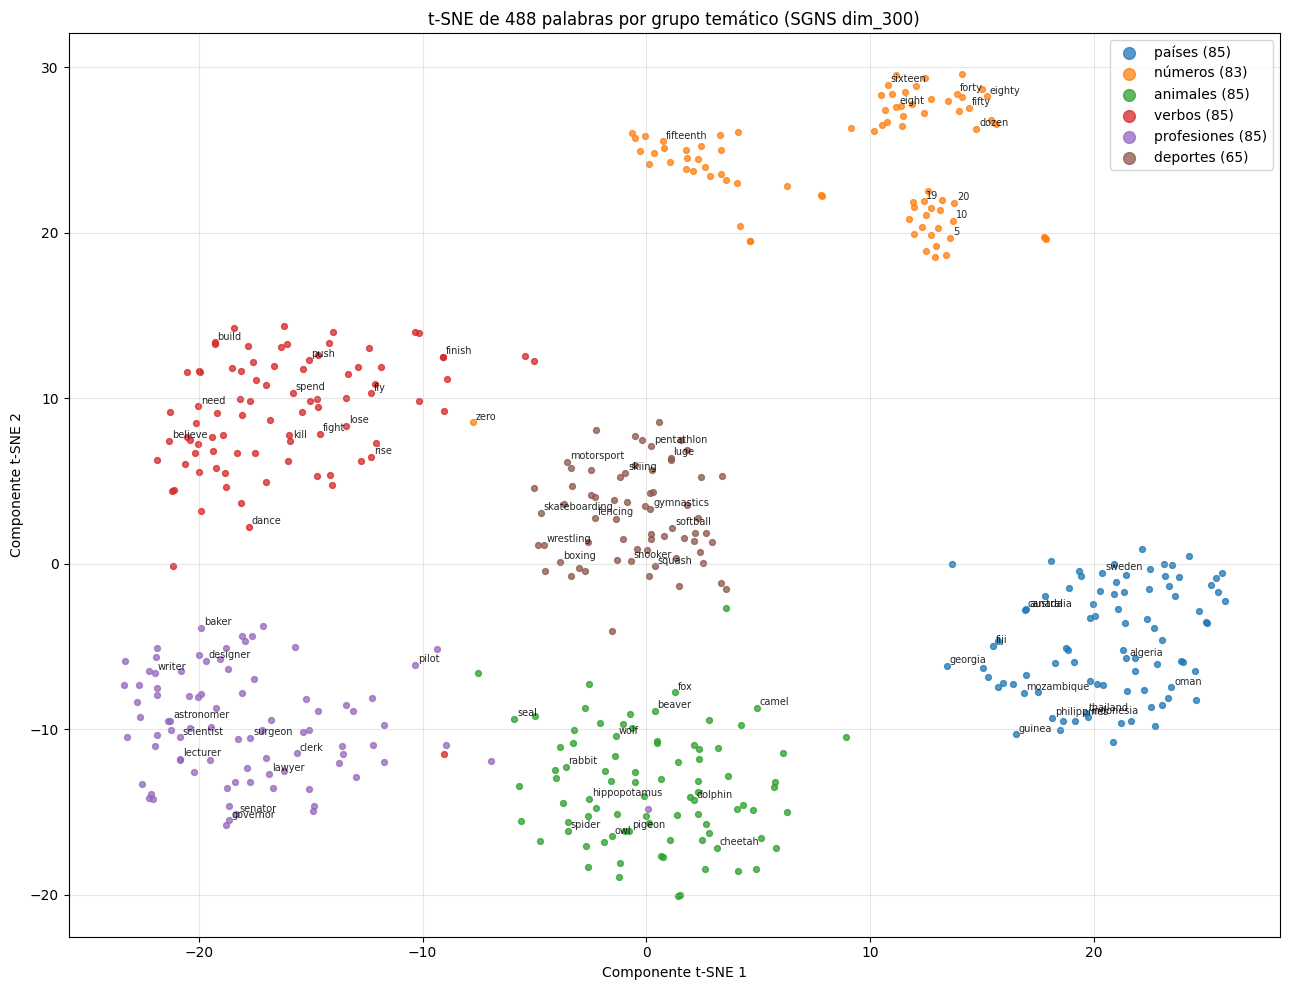

In [48]:
from sklearn.manifold import TSNE

vectores_tsne = np.stack([vectores_sgns[p] for p in palabras_tsne])
coordenadas = TSNE(n_components=2, perplexity=30, metric="cosine", init="pca", random_state=SEED).fit_transform(vectores_tsne)

fig, ax = plt.subplots(figsize=(13, 10))
rng_etiquetas = np.random.default_rng(SEED)
for grupo in GRUPOS_TEMATICOS:
    mascara = etiquetas_tsne == grupo
    ax.scatter(coordenadas[mascara, 0], coordenadas[mascara, 1], s=18, alpha=0.75, label=f"{grupo} ({mascara.sum()})")
    # Se anotan 12 palabras por grupo para no saturar la gráfica
    for i in rng_etiquetas.choice(np.where(mascara)[0], size=min(12, mascara.sum()), replace=False):
        ax.annotate(palabras_tsne[i], coordenadas[i], fontsize=7, alpha=0.85, xytext=(2, 2), textcoords="offset points")
ax.set_title(f"t-SNE de {len(palabras_tsne)} palabras por grupo temático (SGNS {MEJOR_SGNS})")
ax.set_xlabel("Componente t-SNE 1")
ax.set_ylabel("Componente t-SNE 2")
ax.legend(markerscale=2)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "tsne_sgns.png", dpi=150)
plt.show()

## **Análisis de paralelismo**

Las secciones 7 y 8 hacen referencia a una sección 5.3 de paralelismo que no aparece en el enunciado, por lo que se realiza una evaluación breve.

In [49]:
from itertools import combinations


def vectores_diferencia(kv):
    """Vector diferencia normalizado (b - a y d - c) de cada par de las analogías propias, por tipo."""
    U, indice = matriz_normalizada(kv), kv.key_to_index
    diferencias = {}
    for tipo, analogias_tipo in ANALOGIAS_PROPIAS.items():
        pares = [(a, b) for a, b, _, _ in analogias_tipo] + [(c, d) for _, _, c, d in analogias_tipo]
        matriz = np.stack([U[indice[y]] - U[indice[x]] for x, y in pares])
        diferencias[tipo] = matriz / np.linalg.norm(matriz, axis=1, keepdims=True)
    return diferencias


filas = {}
for nombre, kv in MODELOS.items():
    diferencias = vectores_diferencia(kv)
    fila = {tipo: (D @ D.T)[np.triu_indices(len(D), k=1)].mean() for tipo, D in diferencias.items()}
    fila["promedio mismo tipo"] = np.mean(list(fila.values()))
    # Referencia: similitud entre vectores diferencia de tipos distintos
    fila["referencia: tipos distintos"] = np.mean([(D1 @ D2.T).mean() for D1, D2 in combinations(diferencias.values(), 2)])
    filas[nombre] = fila
tabla_paralelismo = pd.DataFrame(filas).round(3)
tabla_paralelismo

,SGNS,gensim,GloVe
género,0.173,0.200,0.571
comparativos,0.207,0.225,0.434
plurales,0.103,0.107,0.316
opuestos,0.050,0.074,0.205
tiempo pasado,0.261,0.277,0.606
promedio mismo tipo,0.159,0.177,0.427
referencia: tipos distintos,0.002,0.001,0.026


**Discusión**

En los tres modelos los vectores diferencia de un mismo tipo tienen una similitud coseno positiva, mientras que entre tipos distintos es prácticamente nula (0.002, 0.001 y 0.026), lo cual indica que sí existe una dirección común para cada relación. No obstante, esta dirección está lejos de ser paralela, ya que la similitud promedio dentro de un mismo tipo es de solo 0.159 en SGNS, 0.177 en gensim y 0.427 en GloVe, frente al valor de 1 que correspondería a una aritmética exacta. Asimismo, el orden coincide con el de los aciertos de la sección anterior, siendo tiempo pasado el tipo más paralelo (0.261, 0.277 y 0.606) y opuestos el menos paralelo (0.050, 0.074 y 0.205). Cabe mencionar que, a diferencia de las analogías, gensim resulta ligeramente más paralelo que SGNS, y que este análisis se realizó únicamente con los 10 pares por tipo de las analogías propias.

---
# **6. Pipeline end-to-end: clasificación de texto**

Para cerrar el pipeline (texto -> tokens -> vectores -> modelo -> salida) se usan los embeddings en la clasificación de AG News en sus 4 categorías, aplicando la misma limpieza (`limpiar_agnews`) y el mismo tokenizador (`tokenizar`) de la sección 2. Se separa el 10 % de train como validación estratificada y el test oficial se reserva para la evaluación final, la cual se realiza una sola vez con la mejor variante de cada inicialización según el F1 de validación.

## **Preparación de los datos**

El vocabulario del clasificador se construye únicamente con train (palabras con al menos 2 apariciones) y las palabras desconocidas se asignan a `<unk>`.

In [50]:
from sklearn.model_selection import train_test_split

MIN_COUNT_NEWS = 2

# 10 % de train como validación estratificada; test oficial reservado para la evaluación final
textos_news_train = news["train"]["text"]
etiquetas_news_train = np.array(news["train"]["label"])
indices_train, indices_val = train_test_split(np.arange(len(textos_news_train)), test_size=0.1,
                                              stratify=etiquetas_news_train, random_state=SEED)

# Mismo pipeline de la sección 2: limpieza propia de AG News y el tokenizador compartido
inicio = time.time()
tokens_news = {
    "train": [tokenizar(limpiar_agnews(textos_news_train[i])) for i in indices_train],
    "val": [tokenizar(limpiar_agnews(textos_news_train[i])) for i in indices_val],
    "test": [tokenizar(limpiar_agnews(texto)) for texto in news["test"]["text"]],
}
y_news = {"train": etiquetas_news_train[indices_train], "val": etiquetas_news_train[indices_val],
          "test": np.array(news["test"]["label"])}
print(f"Tokenización de AG News: {time.time() - inicio:.1f} s")
for split in tokens_news:
    print(f"{split}: {len(tokens_news[split]):,} noticias, "
          f"{sum(map(len, tokens_news[split])) / len(tokens_news[split]):.1f} tokens promedio, "
          f"clases {np.bincount(y_news[split]).tolist()}")

# Vocabulario del clasificador, construido solo con train
conteo_news = Counter(token for documento in tokens_news["train"] for token in documento)
itos_news = TOKENS_ESPECIALES + [p for p, n in conteo_news.most_common() if n >= MIN_COUNT_NEWS]
stoi_news = {p: i for i, p in enumerate(itos_news)}
print(f"Vocabulario del clasificador (min_count = {MIN_COUNT_NEWS}): {len(itos_news):,}")

Tokenización de AG News: 13.3 s
train: 108,000 noticias, 37.7 tokens promedio, clases [27000, 27000, 27000, 27000]
val: 12,000 noticias, 37.8 tokens promedio, clases [3000, 3000, 3000, 3000]
test: 7,600 noticias, 37.6 tokens promedio, clases [1900, 1900, 1900, 1900]
Vocabulario del clasificador (min_count = 2): 49,042


## **Tokens fuera del vocabulario**

Porcentaje de los tokens de AG News (train, validación y test) que no tienen vector en cada conjunto de embeddings.

In [51]:
conteo_tokens_news = Counter(token for split in tokens_news.values() for documento in split for token in documento)
total_tokens_news = sum(conteo_tokens_news.values())

tabla_oov = pd.DataFrame({
    nombre: {
        "vocabulario_embeddings": f"{len(kv):,}",
        "tokens_oov_%": round(100 * sum(n for p, n in conteo_tokens_news.items() if p not in kv.key_to_index) / total_tokens_news, 2),
        "palabras_distintas_oov_%": round(100 * sum(p not in kv.key_to_index for p in conteo_tokens_news) / len(conteo_tokens_news), 2),
    }
    for nombre, kv in MODELOS.items()
}).T
print(f"Tokens de AG News (train, validación y test): {total_tokens_news:,} | palabras distintas: {len(conteo_tokens_news):,}")
tabla_oov

Tokens de AG News (train, validación y test): 4,807,338 | palabras distintas: 85,623


,vocabulario_embeddings,tokens_oov_%,palabras_distintas_oov_%
SGNS,"87,487",3.79,51.39
gensim,"87,487",3.79,51.39
GloVe,"400,000",0.83,23.31


**Discusión**

GloVe deja sin vector únicamente el 0.83 % de los tokens de AG News, frente al 3.79 % de SGNS y gensim, ya que su vocabulario es de 400,000 palabras frente a 87,487. La diferencia es mayor al contar palabras distintas (23.31 % frente a 51.39 %), por lo que más de la mitad del vocabulario de AG News no tiene vector en nuestros modelos, aunque, como se observó con la ley de Zipf, se trata principalmente de palabras poco frecuentes.

## **Baseline: TF-IDF + regresión logística**

El baseline usa los mismos tokens del pipeline, con unigramas y bigramas que aparecen al menos 2 veces en train.

In [52]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

DIR_CLASIFICACION = DIR_RESULTADOS / "clasificacion"
DIR_CLASIFICACION.mkdir(exist_ok=True)


def metricas_clasificacion(y_real, y_pred):
    """Accuracy, precision, recall y F1 macro."""
    precision, recall, f1, _ = precision_recall_fscore_support(y_real, y_pred, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y_real, y_pred), "precision": precision, "recall": recall, "f1": f1}


def analizador_bigramas(documento):
    """Unigramas y bigramas a partir de los tokens ya generados por el pipeline."""
    return documento + [f"{a} {b}" for a, b in zip(documento, documento[1:])]


def entrenar_tfidf(nombre="tfidf_logreg", fraccion=1.0):
    """Baseline TF-IDF (unigramas y bigramas) + regresión logística sobre los mismos tokens."""
    ruta = DIR_CLASIFICACION / f"{nombre}.json"
    if ruta.exists():
        return json.loads(ruta.read_text(encoding="utf-8"))
    n = int(fraccion * len(tokens_news["train"]))
    inicio = time.time()
    vectorizador = TfidfVectorizer(analyzer=analizador_bigramas, min_df=MIN_COUNT_NEWS, sublinear_tf=True)
    X_train = vectorizador.fit_transform(tokens_news["train"][:n])
    modelo = LogisticRegression(max_iter=1000, C=10.0).fit(X_train, y_news["train"][:n])
    tiempo = time.time() - inicio
    pred_val = modelo.predict(vectorizador.transform(tokens_news["val"]))
    joblib.dump((vectorizador, modelo), DIR_MODELOS / f"{nombre}.joblib")
    parametros = modelo.coef_.size + modelo.intercept_.size
    registro = {
        "nombre": nombre, "fraccion_train": fraccion, "n_train": n, "caracteristicas": X_train.shape[1],
        "parametros_totales": int(parametros), "parametros_entrenables": int(parametros), "tiempo_s": tiempo,
        "validacion": metricas_clasificacion(y_news["val"], pred_val),
    }
    ruta.write_text(json.dumps(registro, ensure_ascii=False), encoding="utf-8")
    return registro


registro_tfidf = entrenar_tfidf()
print(f"Características: {registro_tfidf['caracteristicas']:,} | parámetros: {registro_tfidf['parametros_totales']:,} | "
      f"tiempo: {registro_tfidf['tiempo_s']:.1f} s")
pd.Series(registro_tfidf["validacion"]).round(4)

Características: 423,172 | parámetros: 1,692,692 | tiempo: 22.7 s


accuracy     0.9217
precision    0.9216
recall       0.9217
f1           0.9216
dtype: float64

## **Clasificador con EmbeddingBag**

Todos los modelos con embeddings usan el mismo clasificador: `nn.EmbeddingBag` con promedio, seguido de un MLP con una capa oculta de 256 unidades, ReLU y dropout de 0.3. Se entrenan con Adam (learning rate 1e-3), batch de 256 y early stopping con paciencia de 2 epochs sobre la pérdida de validación (máximo 30), conservando los pesos de la mejor epoch. La tabla aleatoria tiene dimensión 300, igual que el mejor SGNS, mientras que las inicializadas con SGNS (300) y GloVe (100) copian el vector de cada palabra del vocabulario del clasificador y dejan en ceros las que no tienen vector. En la variante congelada (`freeze=True`) solo se entrena el MLP, y en la de fine-tuning también se actualiza la tabla.

In [53]:
DIM_ALEATORIA = 300
OCULTA_MLP = 256
DROPOUT_MLP = 0.3
EPOCHS_MAX_CLASIFICADOR = 30
PACIENCIA = 2
BATCH_CLASIFICADOR = 256
LR_CLASIFICADOR = 1e-3

ids_news = {split: [np.array([stoi_news.get(t, ID_UNK) for t in documento], dtype=np.int64) for documento in documentos]
            for split, documentos in tokens_news.items()}


def lotes(split, n=None, mezclar=False, rng=None):
    """Genera lotes (ids concatenados, offsets, etiquetas) en el formato que espera nn.EmbeddingBag."""
    documentos, etiquetas = ids_news[split][:n], y_news[split][:n]
    orden = rng.permutation(len(documentos)) if mezclar else np.arange(len(documentos))
    for inicio in range(0, len(orden), BATCH_CLASIFICADOR):
        seleccion = orden[inicio:inicio + BATCH_CLASIFICADOR]
        # Un documento vacío se representa con <unk> para que la bolsa no quede vacía
        docs = [documentos[i] if len(documentos[i]) else np.array([ID_UNK]) for i in seleccion]
        offsets_lote = np.cumsum([0] + [len(d) for d in docs[:-1]])
        yield (torch.from_numpy(np.concatenate(docs)).to(DEVICE), torch.from_numpy(offsets_lote).to(DEVICE),
               torch.from_numpy(etiquetas[seleccion]).to(DEVICE))


def matriz_inicial(inicializacion):
    """Tabla inicial: aleatoria, o con los vectores preentrenados y ceros para las palabras sin vector."""
    if inicializacion == "aleatoria":
        return torch.randn(len(itos_news), DIM_ALEATORIA), 0
    kv = MODELOS[inicializacion]
    matriz = np.zeros((len(itos_news), kv.vector_size), dtype=np.float32)
    encontradas = 0
    for i, palabra in enumerate(itos_news[len(TOKENS_ESPECIALES):], start=len(TOKENS_ESPECIALES)):
        if palabra in kv.key_to_index:
            matriz[i] = kv[palabra]
            encontradas += 1
    return torch.from_numpy(matriz), encontradas


class ClasificadorBolsa(nn.Module):
    """nn.EmbeddingBag (promedio) + MLP de una capa oculta."""

    def __init__(self, embeddings, congelar):
        super().__init__()
        self.embedding = nn.EmbeddingBag.from_pretrained(embeddings, freeze=congelar, mode="mean")
        self.mlp = nn.Sequential(nn.Linear(embeddings.shape[1], OCULTA_MLP), nn.ReLU(), nn.Dropout(DROPOUT_MLP),
                                 nn.Linear(OCULTA_MLP, len(NOMBRES_CLASES)))

    def forward(self, ids, offsets):
        return self.mlp(self.embedding(ids, offsets))


def predecir(modelo, split):
    """Pérdida promedio y predicciones del modelo sobre un split completo."""
    modelo.eval()
    perdida, predicciones = 0.0, []
    with torch.no_grad():
        for ids, offs, y in lotes(split):
            logits = modelo(ids, offs)
            perdida += F.cross_entropy(logits, y, reduction="sum").item()
            predicciones.append(logits.argmax(1).cpu().numpy())
    return perdida / len(y_news[split]), np.concatenate(predicciones)


def predecir_test(nombre, inicializacion=None, congelar=None):
    """Carga el modelo guardado y predice el conjunto de test."""
    if inicializacion is None:
        vectorizador, modelo = joblib.load(DIR_MODELOS / f"{nombre}.joblib")
        return modelo.predict(vectorizador.transform(tokens_news["test"]))
    modelo = ClasificadorBolsa(matriz_inicial(inicializacion)[0], congelar).to(DEVICE)
    modelo.load_state_dict(torch.load(DIR_MODELOS / f"clasificador_{nombre}.pt"))
    return predecir(modelo, "test")[1]


def entrenar_clasificador(nombre, inicializacion, congelar, fraccion=1.0):
    """Entrena con early stopping por pérdida de validación; si ya existe el registro, lo carga."""
    ruta = DIR_CLASIFICACION / f"{nombre}.json"
    if ruta.exists():
        return json.loads(ruta.read_text(encoding="utf-8"))
    fijar_semilla()
    rng = np.random.default_rng(SEED)
    n = int(fraccion * len(ids_news["train"]))
    embeddings, encontradas = matriz_inicial(inicializacion)
    modelo = ClasificadorBolsa(embeddings, congelar).to(DEVICE)
    optimizador = torch.optim.Adam([p for p in modelo.parameters() if p.requires_grad], lr=LR_CLASIFICADOR)

    historial, mejor_perdida, mejor_estado, sin_mejora = [], np.inf, None, 0
    inicio = time.time()
    for epoch in range(1, EPOCHS_MAX_CLASIFICADOR + 1):
        modelo.train()
        suma, vistos = 0.0, 0
        for ids, offs, y in lotes("train", n, mezclar=True, rng=rng):
            perdida = F.cross_entropy(modelo(ids, offs), y)
            optimizador.zero_grad(set_to_none=True)
            perdida.backward()
            optimizador.step()
            suma += perdida.item() * len(y)
            vistos += len(y)
        perdida_val, _ = predecir(modelo, "val")
        historial.append({"epoch": epoch, "perdida_train": suma / vistos, "perdida_val": perdida_val})
        if perdida_val < mejor_perdida:
            mejor_perdida, sin_mejora = perdida_val, 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= PACIENCIA:
                break
    sincronizar()
    tiempo = time.time() - inicio

    modelo.load_state_dict(mejor_estado)
    torch.save(mejor_estado, DIR_MODELOS / f"clasificador_{nombre}.pt")
    _, pred_val = predecir(modelo, "val")
    registro = {
        "nombre": nombre, "inicializacion": inicializacion, "congelada": congelar, "fraccion_train": fraccion, "n_train": n,
        "dim": embeddings.shape[1], "palabras_con_vector": encontradas, "vocabulario": len(itos_news),
        "parametros_totales": sum(p.numel() for p in modelo.parameters()),
        "parametros_entrenables": sum(p.numel() for p in modelo.parameters() if p.requires_grad),
        "tiempo_s": tiempo, "mejor_epoch": int(np.argmin([h["perdida_val"] for h in historial])) + 1,
        "historial": historial, "validacion": metricas_clasificacion(y_news["val"], pred_val),
    }
    ruta.write_text(json.dumps(registro, ensure_ascii=False), encoding="utf-8")
    print(f"[{nombre}] F1 val {registro['validacion']['f1']:.4f}, epochs {len(historial)}, {tiempo:.1f} s")
    return registro

## **Entrenamiento y comparación en validación**

In [54]:
CLASIFICADORES = {
    "aleatoria": ("aleatoria", False),
    "sgns_congelada": ("SGNS", True),
    "sgns_finetuning": ("SGNS", False),
    "glove_congelada": ("GloVe", True),
    "glove_finetuning": ("GloVe", False),
}
registro_clasificacion = {"tfidf_logreg": registro_tfidf}
for nombre, (inicializacion, congelar) in CLASIFICADORES.items():
    registro_clasificacion[nombre] = entrenar_clasificador(nombre, inicializacion, congelar)

tabla_clasificacion = pd.DataFrame({
    nombre: {
        **{f"{k}_val": round(v, 4) for k, v in r["validacion"].items()},
        "parametros_totales": f"{r['parametros_totales']:,}", "parametros_entrenables": f"{r['parametros_entrenables']:,}",
        "epochs": len(r.get("historial", [])) or "-", "tiempo_s": round(r["tiempo_s"], 1),
    }
    for nombre, r in registro_clasificacion.items()
}).T
tabla_clasificacion

[aleatoria] F1 val 0.9109, epochs 6, 51.6 s
[sgns_congelada] F1 val 0.8952, epochs 16, 16.4 s
[sgns_finetuning] F1 val 0.9189, epochs 4, 35.0 s
[glove_congelada] F1 val 0.9062, epochs 26, 30.1 s
[glove_finetuning] F1 val 0.9198, epochs 6, 20.2 s


,accuracy_val,precision_val,recall_val,f1_val,parametros_totales,parametros_entrenables,epochs,tiempo_s
tfidf_logreg,0.9217,0.9216,0.9217,0.9216,"1,692,692","1,692,692",-,22.7
aleatoria,0.9109,0.9112,0.9109,0.9109,"14,790,684","14,790,684",6,51.6
sgns_congelada,0.8952,0.8956,0.8952,0.8952,"14,790,684","78,084",16,16.4
sgns_finetuning,0.919,0.9193,0.919,0.9189,"14,790,684","14,790,684",4,35.0
glove_congelada,0.9064,0.9067,0.9064,0.9062,"4,931,084","26,884",26,30.1
glove_finetuning,0.9199,0.9201,0.9199,0.9198,"4,931,084","4,931,084",6,20.2


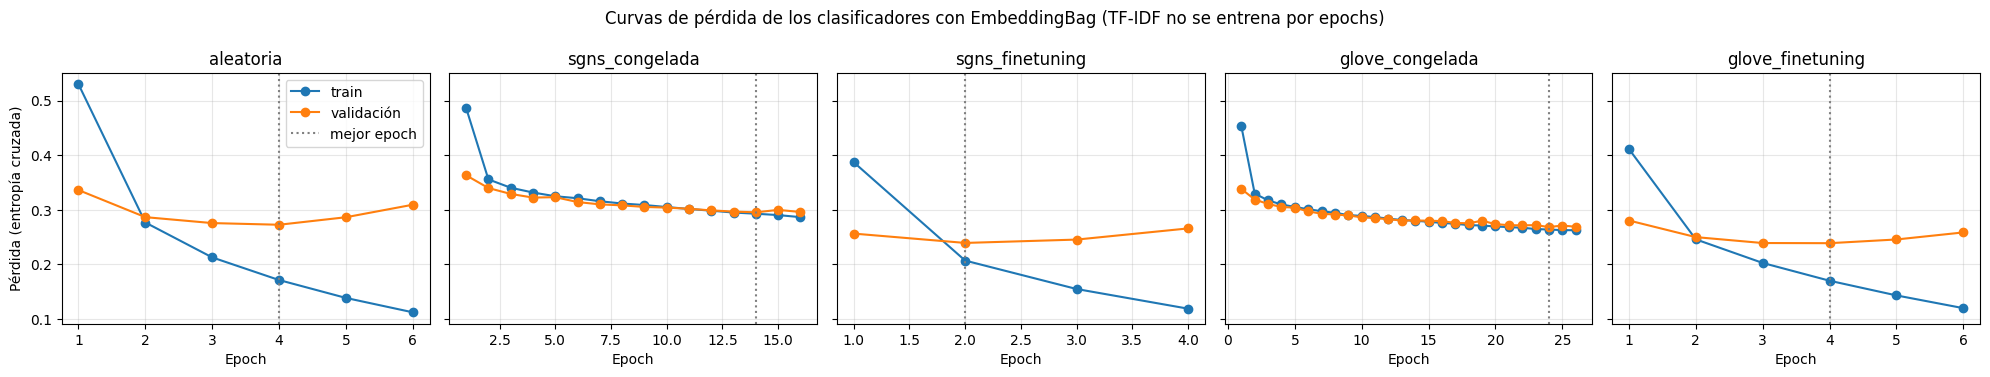

In [55]:
fig, ejes = plt.subplots(1, len(CLASIFICADORES), figsize=(4 * len(CLASIFICADORES), 3.8), sharey=True)
for ax, nombre in zip(ejes, CLASIFICADORES):
    historial = registro_clasificacion[nombre]["historial"]
    epochs = [h["epoch"] for h in historial]
    ax.plot(epochs, [h["perdida_train"] for h in historial], marker="o", label="train")
    ax.plot(epochs, [h["perdida_val"] for h in historial], marker="o", label="validación")
    ax.axvline(registro_clasificacion[nombre]["mejor_epoch"], color="gray", linestyle=":", label="mejor epoch")
    ax.set_title(nombre)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
ejes[0].set_ylabel("Pérdida (entropía cruzada)")
ejes[0].legend()
fig.suptitle("Curvas de pérdida de los clasificadores con EmbeddingBag (TF-IDF no se entrena por epochs)")
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "curvas_clasificacion.png", dpi=150)
plt.show()

**Discusión**

En validación el baseline TF-IDF obtuvo el mayor F1 (0.9216), seguido muy de cerca por GloVe (0.9198) y SGNS (0.9189) con fine-tuning, mientras que la tabla aleatoria alcanzó 0.9109 y las variantes congeladas fueron las más bajas (0.9062 y 0.8952), aunque entrenan menos de 80,000 parámetros. Asimismo, las curvas muestran que las variantes con fine-tuning alcanzan su menor pérdida de validación entre las epochs 2 y 4 y después esta aumenta mientras la de train sigue bajando, señal de overfitting que el early stopping detiene, mientras que las congeladas mejoran lentamente hasta las epochs 14 y 24 sin sobreajustar.

## **Evaluación final en test**

Mejores variantes por validación: {'TF-IDF': 'tfidf_logreg', 'Aleatoria': 'aleatoria', 'SGNS': 'sgns_finetuning', 'GloVe': 'glove_finetuning'}


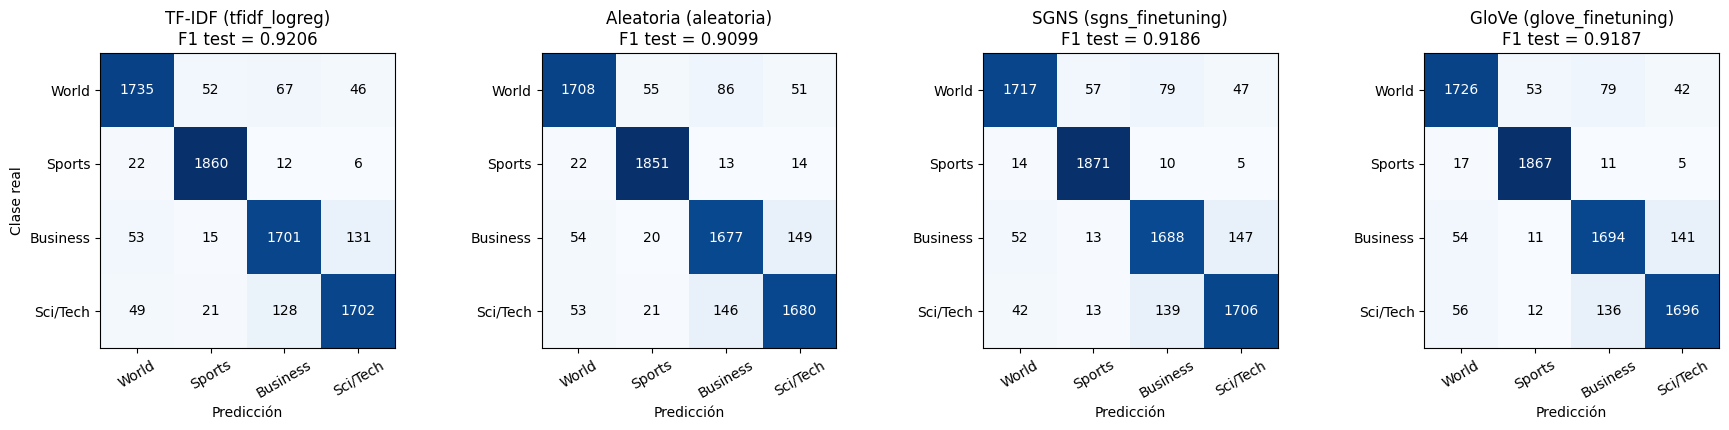

,modelo,accuracy,precision,recall,f1
TF-IDF,tfidf_logreg,0.920789,0.920638,0.920789,0.920644
Aleatoria,aleatoria,0.91,0.910003,0.91,0.909893
SGNS,sgns_finetuning,0.918684,0.918721,0.918684,0.918557
GloVe,glove_finetuning,0.918816,0.918713,0.918816,0.918688


In [56]:
RUTA_TEST = DIR_CLASIFICACION / "evaluacion_test.json"

# La mejor variante de cada inicialización se elige por F1 de validación
mejores_variantes = {"TF-IDF": "tfidf_logreg", "Aleatoria": "aleatoria"}
for inicializacion in ("SGNS", "GloVe"):
    variantes = [n for n, (ini, _) in CLASIFICADORES.items() if ini == inicializacion]
    mejores_variantes[inicializacion] = max(variantes, key=lambda n: registro_clasificacion[n]["validacion"]["f1"])
print(f"Mejores variantes por validación: {mejores_variantes}")

# El test se evalúa una sola vez y el resultado se reutiliza
if RUTA_TEST.exists():
    evaluacion_test = json.loads(RUTA_TEST.read_text(encoding="utf-8"))
else:
    evaluacion_test = {}
    for inicializacion, nombre in mejores_variantes.items():
        pred_test = predecir_test(nombre, *CLASIFICADORES.get(nombre, (None, None)))
        evaluacion_test[inicializacion] = {"modelo": nombre, **metricas_clasificacion(y_news["test"], pred_test),
                                           "pred_test": pred_test.tolist()}
    RUTA_TEST.write_text(json.dumps(evaluacion_test, ensure_ascii=False, indent=1), encoding="utf-8")

fig, ejes = plt.subplots(1, len(mejores_variantes), figsize=(4.5 * len(mejores_variantes), 4.2))
for ax, (inicializacion, nombre) in zip(ejes, mejores_variantes.items()):
    matriz = confusion_matrix(y_news["test"], evaluacion_test[inicializacion]["pred_test"])
    ax.imshow(matriz, cmap="Blues")
    for i in range(len(NOMBRES_CLASES)):
        for j in range(len(NOMBRES_CLASES)):
            ax.text(j, i, matriz[i, j], ha="center", va="center", color="white" if matriz[i, j] > matriz.max() / 2 else "black")
    ax.set_xticks(range(len(NOMBRES_CLASES)), NOMBRES_CLASES, rotation=30)
    ax.set_yticks(range(len(NOMBRES_CLASES)), NOMBRES_CLASES)
    ax.set_title(f"{inicializacion} ({nombre})\nF1 test = {evaluacion_test[inicializacion]['f1']:.4f}")
    ax.set_xlabel("Predicción")
ejes[0].set_ylabel("Clase real")
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "matrices_confusion.png", dpi=150)
plt.show()

pd.DataFrame(evaluacion_test).T.drop(columns="pred_test")

**Discusión**

En test, la mejor variante de SGNS y GloVe fue la de fine-tuning, con un F1 de 0.9186 y 0.9187, prácticamente iguales entre sí y por encima de la tabla aleatoria (0.9099), aunque el baseline TF-IDF se mantuvo ligeramente superior (0.9206). En las cuatro matrices de confusión la principal confusión ocurre entre Business y Sci/Tech (entre 128 y 149 noticias en cada dirección), probablemente porque comparten vocabulario sobre empresas y productos, mientras que Sports es la clase mejor clasificada, con un recall de entre 0.974 y 0.985.

## **Correlación en SimLex-999**

SimLex-999 mide similitud estricta (por ejemplo, "old" y "new" están relacionadas pero no son similares), a diferencia de WordSim-353, que también premia la relación temática. Se reservó hasta esta sección para no usarla en la selección de configuraciones.

In [57]:
filas = {}
for nombre, kv in MODELOS.items():
    # evaluate_word_pairs devuelve (Pearson, Spearman, porcentaje de pares fuera del vocabulario)
    _, spearman_simlex, oov_simlex = kv.evaluate_word_pairs(simlex)
    filas[nombre] = {"simlex_spearman": round(float(spearman_simlex[0]), 4), "pares_fuera_vocabulario_%": round(oov_simlex, 2),
                     "wordsim_spearman": round(float(kv.evaluate_word_pairs(wordsim)[1][0]), 4)}
tabla_simlex = pd.DataFrame(filas).T
tabla_simlex

,simlex_spearman,pares_fuera_vocabulario_%,wordsim_spearman
SGNS,0.3229,0.6,0.6836
gensim,0.3405,0.6,0.6422
GloVe,0.2961,0.1,0.5327


**Discusión**

En SimLex-999 las correlaciones son considerablemente menores que en WordSim-353 para los tres modelos (0.323, 0.341 y 0.296 frente a 0.684, 0.642 y 0.533), ya que los embeddings basados en co-ocurrencia acercan tanto palabras similares como palabras solo relacionadas, por ejemplo antónimos como "old" y "new". Gensim obtuvo la correlación más alta y GloVe la más baja, por lo que, al igual que en WordSim, el mayor corpus de GloVe no se tradujo en una mejor correlación con los juicios humanos de similitud.

---
# **7. Comparación de resultados**

## **Clasificador con Word2Vec de gensim**

La tabla comparativa incluye el F1 de test de los tres conjuntos de embeddings, por lo que se entrena el mismo clasificador de la sección 6 con los vectores de gensim, en sus variantes congelada y con fine-tuning, y se evalúa en test únicamente la mejor según el F1 de validación.

In [58]:
# La tabla pide el F1 de test de los tres conjuntos, por lo que también se entrena el clasificador con gensim
CLASIFICADORES_GENSIM = {"gensim_congelada": ("gensim", True), "gensim_finetuning": ("gensim", False)}
for nombre, (inicializacion, congelar) in CLASIFICADORES_GENSIM.items():
    registro_clasificacion[nombre] = entrenar_clasificador(nombre, inicializacion, congelar)
mejores_variantes["gensim"] = max(CLASIFICADORES_GENSIM, key=lambda n: registro_clasificacion[n]["validacion"]["f1"])

RUTA_TEST_GENSIM = DIR_CLASIFICACION / "evaluacion_test_gensim.json"
if RUTA_TEST_GENSIM.exists():
    evaluacion_test["gensim"] = json.loads(RUTA_TEST_GENSIM.read_text(encoding="utf-8"))
else:
    nombre = mejores_variantes["gensim"]
    pred_test = predecir_test(nombre, *CLASIFICADORES_GENSIM[nombre])
    evaluacion_test["gensim"] = {"modelo": nombre, **metricas_clasificacion(y_news["test"], pred_test), "pred_test": pred_test.tolist()}
    RUTA_TEST_GENSIM.write_text(json.dumps(evaluacion_test["gensim"], ensure_ascii=False, indent=1), encoding="utf-8")

pd.DataFrame({n: {**{f"{k}_val": round(v, 4) for k, v in registro_clasificacion[n]["validacion"].items()},
                  "epochs": len(registro_clasificacion[n]["historial"])} for n in CLASIFICADORES_GENSIM}).T

[gensim_congelada] F1 val 0.8957, epochs 22, 22.3 s
[gensim_finetuning] F1 val 0.9177, epochs 4, 31.3 s


,accuracy_val,precision_val,recall_val,f1_val,epochs
gensim_congelada,0.8960,0.8963,0.8960,0.8957,22.0
gensim_finetuning,0.9178,0.9181,0.9178,0.9177,4.0


## **Tabla comparativa**

Las analogías corresponden a la evaluación con vocabulario compartido de la sección 5.2, la similitud entre vectores diferencia al análisis de paralelismo y el F1 de test a la mejor variante de cada conjunto. Para GloVe, el tiempo y el hardware son los reportados por Pennington et al. (2014).

In [59]:
def accuracy_benchmark(nombre, metodo, mascara):
    """Accuracy (%) de la sección 5.2 (vocabulario compartido) para un grupo de preguntas."""
    return round(100 * aciertos[(nombre, metodo)][mascara].mean(), 2)


grupos_analogias = {"semánticas": ~es_sintactica, "sintácticas": es_sintactica, "total": np.ones(len(preguntas), dtype=bool)}
info_modelos = {
    "SGNS": {"tokens": registro_sgns[MEJOR_SGNS]["tokens_corpus"], "vocabulario": len(vectores_sgns), "dim": vectores_sgns.vector_size,
             "tiempo": f"{registro_sgns[MEJOR_SGNS]['tiempo_entrenamiento_s'] / 60:.1f} min (5 epochs)",
             "hardware": "Apple M4, GPU con MPS, 16 GB de memoria unificada"},
    "gensim": {"tokens": registro_gensim["tokens_corpus"], "vocabulario": len(vectores_gensim), "dim": vectores_gensim.vector_size,
               "tiempo": f"{sum(h['tiempo_epoch_s'] for h in registro_gensim['historial']) / 60:.1f} min (5 epochs)",
               "hardware": f"Apple M4, CPU con {registro_gensim['config']['workers']} hilos"},
    "GloVe": {"tokens": registro_glove["tokens_corpus"], "vocabulario": len(glove), "dim": glove.vector_size,
              "tiempo": "matriz X: aprox. 85 min (1 hilo); 14 min por iteración en 300d con 32 núcleos (no reportado para 100d)",
              "hardware": "Intel Xeon E5-2658 dual a 2.1 GHz (Pennington et al., 2014)"},
}

tabla_comparativa = {}
for nombre in MODELOS:
    info = info_modelos[nombre]
    columna = {"tokens del corpus": f"{info['tokens']:,}", "vocabulario": f"{info['vocabulario']:,}", "dimensión": info["dim"],
               "tiempo de entrenamiento": info["tiempo"], "hardware": info["hardware"]}
    for metodo in ("3CosAdd", "3CosMul"):
        for grupo, mascara in grupos_analogias.items():
            columna[f"analogías {grupo} {metodo} (%)"] = accuracy_benchmark(nombre, metodo, mascara)
    columna["Spearman WordSim-353"] = tabla_simlex.loc[nombre, "wordsim_spearman"]
    columna["Spearman SimLex-999"] = tabla_simlex.loc[nombre, "simlex_spearman"]
    columna["coseno promedio vectores diferencia"] = tabla_paralelismo.loc["promedio mismo tipo", nombre]
    columna["tokens OOV en AG News (%)"] = tabla_oov.loc[nombre, "tokens_oov_%"]
    columna["F1 test AG News"] = f"{evaluacion_test[nombre]['f1']:.4f} ({evaluacion_test[nombre]['modelo']})"
    tabla_comparativa[nombre] = columna

pd.set_option("display.max_colwidth", 120)
tabla_comparativa = pd.DataFrame(tabla_comparativa)
tabla_comparativa

,SGNS,gensim,GloVe
tokens del corpus,"19,662,943","19,662,943","6,000,000,000"
vocabulario,"87,487","87,487","400,000"
dimensión,300,300,100
tiempo de entrenamiento,22.3 min (5 epochs),2.3 min (5 epochs),matriz X: aprox. 85 min (1 hilo); 14 min por iteración en 300d con 32 núcleos (no reportado para 100d)
hardware,"Apple M4, GPU con MPS, 16 GB de memoria unificada","Apple M4, CPU con 10 hilos","Intel Xeon E5-2658 dual a 2.1 GHz (Pennington et al., 2014)"
analogías semánticas 3CosAdd (%),41.7,25.77,60.56
analogías sintácticas 3CosAdd (%),48.06,45.53,68.02
analogías total 3CosAdd (%),46.02,39.19,65.63
analogías semánticas 3CosMul (%),39.84,26.09,58.12
analogías sintácticas 3CosMul (%),46.36,45.23,66.74


## **Accuracy de analogías contra tokens del corpus**

Se grafica el accuracy total de analogías de la última epoch de cada iteración (evaluación de la sección 4), con GloVe como línea de referencia.

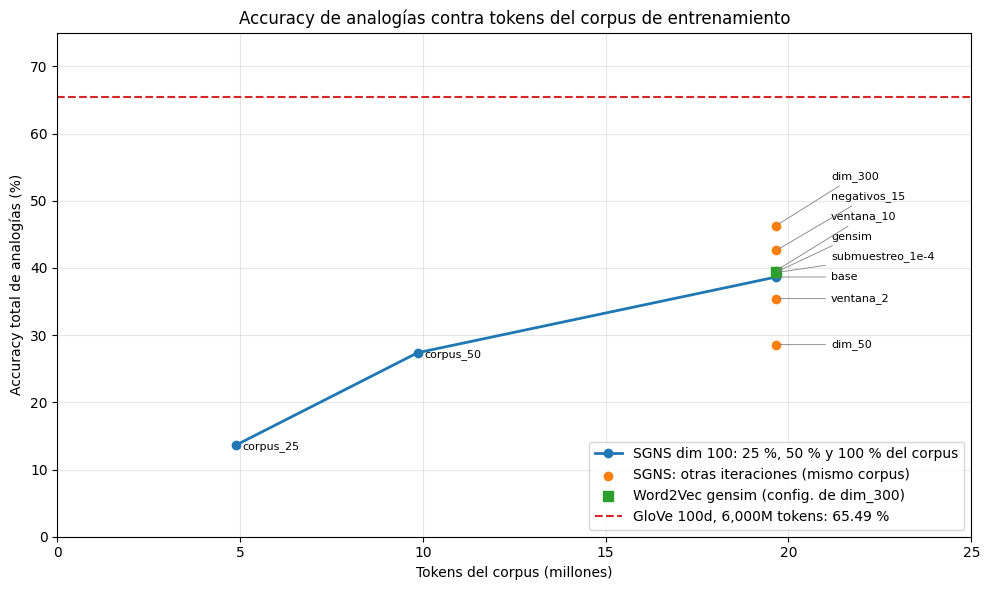

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))
serie_corpus = ["corpus_25", "corpus_50", "base"]
ax.plot([registro_sgns[n]["tokens_corpus"] / 1e6 for n in serie_corpus],
        [100 * registro_sgns[n]["historial"][-1]["analogias_total"] for n in serie_corpus],
        "-o", linewidth=2, label="SGNS dim 100: 25 %, 50 % y 100 % del corpus")
otras = [n for n in registro_sgns if n not in serie_corpus]
ax.scatter([registro_sgns[n]["tokens_corpus"] / 1e6 for n in otras],
           [100 * registro_sgns[n]["historial"][-1]["analogias_total"] for n in otras],
           color="tab:orange", zorder=3, label="SGNS: otras iteraciones (mismo corpus)")
ax.scatter(registro_gensim["tokens_corpus"] / 1e6, 100 * registro_gensim["historial"][-1]["analogias_total"],
           marker="s", color="tab:green", s=60, zorder=3, label="Word2Vec gensim (config. de dim_300)")
puntos = {n: (registro_sgns[n]["tokens_corpus"] / 1e6, 100 * registro_sgns[n]["historial"][-1]["analogias_total"])
          for n in registro_sgns}
puntos["gensim"] = (registro_gensim["tokens_corpus"] / 1e6, 100 * registro_gensim["historial"][-1]["analogias_total"])
# Las iteraciones con el corpus completo comparten x, por lo que sus etiquetas se separan verticalmente
y_etiqueta = -np.inf
for n, (x, y) in sorted(puntos.items(), key=lambda item: item[1][1]):
    if x < 15:
        ax.annotate(n, (x, y), fontsize=8, xytext=(5, -3), textcoords="offset points")
        continue
    y_etiqueta = max(y, y_etiqueta + 3)
    ax.annotate(n, (x, y), xytext=(x + 1.5, y_etiqueta), fontsize=8, va="center",
                arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.6})
ax.axhline(100 * registro_glove["analogias_total"], color="tab:red", linestyle="--",
           label=f"GloVe 100d, 6,000M tokens: {100 * registro_glove['analogias_total']:.2f} %")
ax.set_title("Accuracy de analogías contra tokens del corpus de entrenamiento")
ax.set_xlabel("Tokens del corpus (millones)")
ax.set_ylabel("Accuracy total de analogías (%)")
ax.set_xlim(0, 25)
ax.set_ylim(0, 75)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "analogias_vs_tokens.png", dpi=150)
plt.show()

## **F1-score de test contra fracción de datos de AG News**

Cada inicialización se entrena con el 1 %, 10 %, 50 % y 100 % de train, manteniendo el mismo conjunto de validación para el early stopping. Para SGNS y GloVe se incluyen ambas variantes (congelada y fine-tuning). Cabe mencionar que esta gráfica requiere evaluar en test cada modelo entrenado con una fracción distinta.

[aleatoria_f0.01] F1 val 0.7243, epochs 20, 4.5 s
[aleatoria_f0.1] F1 val 0.8512, epochs 8, 7.0 s
[aleatoria_f0.5] F1 val 0.8954, epochs 6, 22.3 s
[sgns_congelada_f0.01] F1 val 0.8587, epochs 30, 4.3 s
[sgns_congelada_f0.1] F1 val 0.8789, epochs 29, 5.1 s
[sgns_congelada_f0.5] F1 val 0.8914, epochs 24, 10.9 s
[sgns_finetuning_f0.01] F1 val 0.8695, epochs 22, 3.8 s
[sgns_finetuning_f0.1] F1 val 0.8946, epochs 7, 5.9 s
[sgns_finetuning_f0.5] F1 val 0.9130, epochs 4, 15.5 s
[glove_congelada_f0.01] F1 val 0.8715, epochs 30, 2.6 s
[glove_congelada_f0.1] F1 val 0.8911, epochs 24, 3.7 s
[glove_congelada_f0.5] F1 val 0.9024, epochs 27, 12.7 s
[glove_finetuning_f0.01] F1 val 0.8719, epochs 22, 3.2 s
[glove_finetuning_f0.1] F1 val 0.8978, epochs 10, 4.2 s
[glove_finetuning_f0.5] F1 val 0.9122, epochs 6, 9.4 s
Tiempo total: 2.3 min


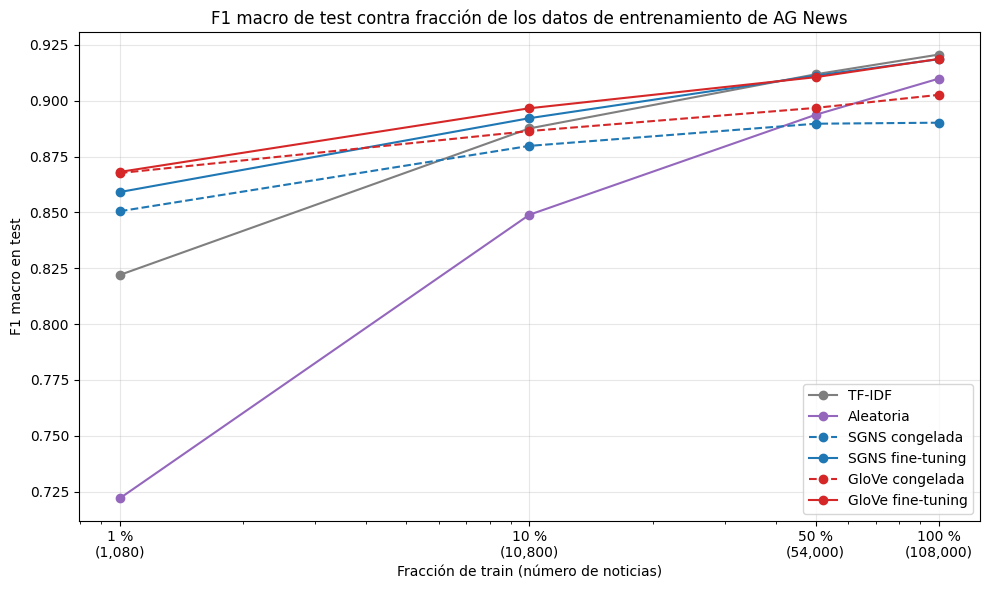

,1 %,10 %,50 %,100 %
TF-IDF,0.8220,0.8876,0.9118,0.9206
Aleatoria,0.7220,0.8489,0.8937,0.9099
SGNS congelada,0.8505,0.8798,0.8897,0.8901
SGNS fine-tuning,0.8591,0.8921,0.9112,0.9186
GloVe congelada,0.8676,0.8864,0.8968,0.9026
GloVe fine-tuning,0.8681,0.8966,0.9105,0.9187


In [61]:
FRACCIONES_NEWS = [0.01, 0.1, 0.5, 1.0]
RUTA_FRACCIONES = DIR_CLASIFICACION / "fracciones_test.json"

# Se incluyen ambas variantes de SGNS y GloVe para comparar congelar y fine-tuning con pocos datos
CURVAS_FRACCION = {
    "TF-IDF": ("tfidf_logreg", None, None), "Aleatoria": ("aleatoria", "aleatoria", False),
    "SGNS congelada": ("sgns_congelada", "SGNS", True), "SGNS fine-tuning": ("sgns_finetuning", "SGNS", False),
    "GloVe congelada": ("glove_congelada", "GloVe", True), "GloVe fine-tuning": ("glove_finetuning", "GloVe", False),
}

if RUTA_FRACCIONES.exists():
    f1_por_fraccion = json.loads(RUTA_FRACCIONES.read_text(encoding="utf-8"))
else:
    inicio = time.time()
    f1_por_fraccion = {}
    for curva, (nombre, inicializacion, congelar) in CURVAS_FRACCION.items():
        f1_por_fraccion[curva] = {}
        for fraccion in FRACCIONES_NEWS:
            nombre_fraccion = nombre if fraccion == 1.0 else f"{nombre}_f{fraccion}"
            if inicializacion is None:
                entrenar_tfidf(nombre_fraccion, fraccion)
            else:
                entrenar_clasificador(nombre_fraccion, inicializacion, congelar, fraccion)
            f1_por_fraccion[curva][str(fraccion)] = metricas_clasificacion(
                y_news["test"], predecir_test(nombre_fraccion, inicializacion, congelar))["f1"]
    RUTA_FRACCIONES.write_text(json.dumps(f1_por_fraccion, indent=1), encoding="utf-8")
    print(f"Tiempo total: {(time.time() - inicio) / 60:.1f} min")

colores = {"TF-IDF": "tab:gray", "Aleatoria": "tab:purple", "SGNS": "tab:blue", "GloVe": "tab:red"}
fig, ax = plt.subplots(figsize=(10, 6))
for curva, valores in f1_por_fraccion.items():
    ax.plot([100 * f for f in FRACCIONES_NEWS], [valores[str(f)] for f in FRACCIONES_NEWS], marker="o",
            color=colores[curva.split()[0]], linestyle="--" if "congelada" in curva else "-", label=curva)
ax.set_xscale("log")
ax.set_xticks([100 * f for f in FRACCIONES_NEWS], [f"{100 * f:g} %\n({int(f * len(ids_news['train'])):,})" for f in FRACCIONES_NEWS])
ax.set_title("F1 macro de test contra fracción de los datos de entrenamiento de AG News")
ax.set_xlabel("Fracción de train (número de noticias)")
ax.set_ylabel("F1 macro en test")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "f1_vs_fraccion.png", dpi=150)
plt.show()

(pd.DataFrame(f1_por_fraccion).T.rename(columns=lambda f: f"{100 * float(f):g} %")).round(4)

---
# **8. Discusión y análisis**

**¿Se cumple la aritmética vectorial en su modelo? ¿En qué categorías de analogías funciona mejor y en cuáles falla? ¿Hay diferencias entre analogías semánticas y sintácticas?**

La aritmética vectorial supone que las relaciones entre palabras son direcciones en el espacio, de tal forma que vec(king) - vec(man) + vec(woman) quede cerca de vec(queen). En nuestro SGNS se cumple de forma parcial, ya que resuelve el 46.02 % de las analogías con vocabulario compartido, funcionando mejor en nacionalidad (74.83 %), capitales comunes (62.62 %) y comparativos (57.70 %), y fallando en currency (0.00 %), adjetivo-adverbio (8.86 %) y opuestos (13.97 %), siendo currency la categoría en la que fallaron los tres modelos. Asimismo, en los tres modelos las sintácticas superan a las semánticas (48.06 % frente a 41.70 % en SGNS), ya que relaciones gramaticales como "go : went" se repiten en cualquier texto, mientras que las semánticas como "athens : greece :: baghdad : iraq" requieren haber visto cada par específico.

**¿Es el "aproximadamente igual" de king - man + woman y queen una igualdad? Usen los resultados sin exclusión de palabras de consulta y el análisis de paralelismo para argumentar.**

No, se trata de una relación de cercanía y no de una igualdad, ya que sin excluir las palabras de la consulta el vector resultante queda más cerca de "king" (0.736) que de "queen" (0.478), y en 21 de las 25 analogías propias de SGNS la primera palabra fue `c`, por lo que "queen" solo aparece en primer lugar al descartar "king". Esto se explica con el análisis de paralelismo, donde los vectores diferencia de género tienen una similitud coseno promedio de apenas 0.173 entre sí, frente al valor de 1 que tendrían si la relación fuera exacta, de tal forma que sumar la dirección de género solo desplaza ligeramente a "king" hacia una región donde "queen" es la palabra más cercana, pero sin llegar a ella.

**¿Qué tan lejos quedó su modelo de GloVe? ¿Cuánto de la diferencia se explica por el tamaño del corpus y cuánto por el método o los hiperparámetros? Usen el experimento de tamaño de corpus para responder.**

Nuestro mejor SGNS quedó 19.6 puntos por debajo de GloVe en analogías (46.02 % frente a 65.63 %), y consideramos que la mayor parte de esta diferencia se explica por el tamaño del corpus, ya que en el experimento de corpus cada duplicación de los tokens aumentó el accuracy entre 11 y 14 puntos (13.61 %, 27.39 % y 38.66 % con 4.9M, 9.9M y 19.7M tokens), mientras que el mejor ajuste de hiperparámetros sobre el mismo corpus, pasar de dimensión 100 a 300, solo aportó 7.7 puntos, y GloVe se entrenó con aproximadamente 300 veces más texto. Esto es consistente con que la brecha se concentra en conocimiento enciclopédico como capital-world (44.86 % frente a 88.96 %), mientras que en tiempo pasado ambos prácticamente empatan (56.90 % frente a 57.68 %). No obstante, cabe mencionar que la ganancia por duplicación ya empieza a disminuir y que no se entrenó GloVe con nuestro corpus, por lo que la proporción exacta entre corpus y método no se puede medir directamente.

**¿Su implementación de SGNS se comporta parecido a la de gensim? Si hay diferencias, ¿a qué se deben?**

Cualitativamente sí, ya que con el mismo corpus, vocabulario e hiperparámetros ambos producen vecinos prácticamente iguales (por ejemplo, "france" con spain, italy, belgium y austria), un accuracy similar en analogías sintácticas (48.06 % frente a 45.53 %) y el mismo desempeño en AG News (F1 de 0.9186 frente a 0.9198). No obstante, nuestro SGNS supera a gensim en las analogías semánticas (41.70 % frente a 25.77 %) y en WordSim (0.684 frente a 0.642), diferencia que atribuimos al optimizador, ya que nuestra implementación usa Adam con batches de 32,768 pares, que ajusta el paso de cada palabra según su historial y favorece a las menos frecuentes como países y capitales, mientras que gensim usa SGD par por par con un learning rate que decae linealmente hasta casi cero. Cabe mencionar que esta causa no se aisló experimentalmente y que, a cambio, gensim entrenó aproximadamente 10 veces más rápido (2.3 frente a 22.3 minutos).

**¿Qué efecto tuvieron la dimensión del embedding, el tamaño de ventana y el número de negativos? ¿Las ventanas pequeñas favorecen relaciones sintácticas o semánticas?**

La dimensión fue el hiperparámetro con mayor impacto, ya que al pasar de 50 a 300 el accuracy de analogías aumentó 17.72 puntos (de 28.59 % a 46.31 %), lo cual consideramos que se debe a que un vector más grande permite representar más rasgos de cada palabra y diferenciarla mejor de las demás, aunque a cambio el tiempo de entrenamiento pasó de 5.0 a 23.4 minutos. Le siguió el número de negativos, que al pasar de 5 a 15 aumentó el accuracy de 38.66 % a 42.61 % pero duplicó el tiempo, mientras que la ventana tuvo un efecto menor en el total (+3.22 puntos de 2 a 5 y +0.96 de 5 a 10). No obstante, la ventana sí cambia el tipo de relación aprendida, ya que las sintácticas se mantienen alrededor del 41 % en las tres ventanas mientras que las semánticas aumentan de 23.80 % a 34.89 %, por lo que las ventanas pequeñas favorecen relativamente las relaciones sintácticas, lo cual se refleja en que con ventana 2 los vecinos de "king" son otros gobernantes como "emperor", mientras que con ventana 10 son palabras del mismo tema como "queen" y "throne".

**En AG News, ¿los embeddings preentrenados superaron a los aleatorios y al baseline TF-IDF? ¿Cuándo convino congelar y cuándo hacer fine-tuning? ¿Cómo cambia la respuesta con 1 % de los datos?**

Con todos los datos, los embeddings preentrenados con fine-tuning superaron a la tabla aleatoria (F1 de test de 0.9187 con GloVe y 0.9186 con SGNS frente a 0.9099), pero no al baseline TF-IDF (0.9206), y convino hacer fine-tuning, ya que las variantes congeladas se estancan al entrenar únicamente el MLP (SGNS congelada obtuvo 0.890 tanto con 50 % como con 100 % de los datos). En cambio, con el 1 % de los datos (1,080 noticias) los preentrenados superan ampliamente a ambos, con 0.868 en GloVe y 0.859 en SGNS frente a 0.822 de TF-IDF y 0.722 de la tabla aleatoria, ya que traen aprendido el significado de las palabras desde Wikipedia, mientras que con tan pocos ejemplos la tabla aleatoria no logra aprenderlo. Asimismo, con el 1 % congelar y hacer fine-tuning dan resultados prácticamente iguales (0.868 en ambas variantes de GloVe), por lo que la ventaja del fine-tuning solo aparece conforme aumentan los datos disponibles.